# iSWAP coupler pulse construction

First task of the iSWAP program (see `ROBUST_ISWAP_PROGRAM.md`).

## What we know from the Hadamard testbed

- Hard spectral constraint `|Ω̂(η)|² ≤ ε_max` inside a 2-lvl optimizer pushes 3-lvl leakage to ~10⁻⁶ (verified honestly).
- Variational σ_z robustness composes cleanly with the notch.
- 2-lvl optimization is capped at ~3-nines by AC Stark + commutator residual; warm-started 3-lvl polish closes the gap (default case → F₃ = 0.99999 in 18 s).
- The framework ports to 2Q via multiple spectral notches at the relevant 2Q leakage frequencies (|η_1|, |η_2|, |11⟩↔|20⟩, |11⟩↔|02⟩) and per-qubit n̂ robustness in the polish step.

## Plan

1. Build `g_eff(t)` as a 200 ns square envelope, hardware-realistic.
2. Apply two cascaded Gaussian filters:
   - **η-killer**: kills spectral content near `|η|/2π ≈ 170 MHz` → suppresses |11⟩↔|20⟩, |11⟩↔|02⟩.
   - **AWG bandwidth**: `B_3dB = 250 MHz` (lab convention).
3. Identify the flat region of the filtered envelope where MW controls can be optimized against a quasi-static coupling. First cut: dashed lines at +5 ns / −5 ns from each edge.
4. Later: 4-dim warm-start optimization, then 3-lvl-per-qubit polish.

In [1]:
import Pkg
Pkg.activate(@__DIR__)

using Piccolo, FFTW, CairoMakie, Printf, LinearAlgebra, Random, SparseArrays
using DirectTrajOpt.Constraints: AbstractNonlinearConstraint
using DirectTrajOpt.CommonInterface

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational`


## Constants

All times in ns, all frequencies in MHz. `g_max` is normalized to 1 for the envelope plot — physical amplitude (in rad/ns) will be set when wiring into the 4-dim 2Q Hamiltonian later.

In [2]:
const T_TOTAL_NS   = 250.0         # time window (with buffer on each side)
const T_PULSE_NS   = 200.0         # nominal flat-top duration of the square
const T_RISE       = 25.0          # rising edge starts here
const T_FALL       = T_RISE + T_PULSE_NS
const T_EDGE_MARK  = 10.0           # margin (ns) for marking the flat region

const N_FINE = 16384
const dt_fine = T_TOTAL_NS / N_FINE   # ns per grid point  (≈ 0.0153 ns)

const η_MHz     = 170.0            # |anharmonicity|/2π
const B_AWG_MHz = 250.0            # hardware AWG -3dB bandwidth

const g_max     = 1.0              # placeholder amplitude (normalized)

# Filter widths:
#   AWG:   σ_f = B_3dB / √(ln 2)        (matches CLAUDE.md convention)
#   η:     σ_f chosen so G(η) ≈ exp(-η²/(2σ²)) gives strong suppression.
#         At σ_f = 50 MHz, G(170) = exp(-170²/(2·50²)) = exp(-5.78) ≈ 3.1e-3.
const σ_f_anh_MHz = 50.0
const σ_f_AWG_MHz = B_AWG_MHz / sqrt(log(2))

@printf("dt_fine        = %.5f ns\n", dt_fine)
@printf("σ_f (η-kill)   = %.1f MHz   →  G(η=%.0f) = %.3e\n",
    σ_f_anh_MHz, η_MHz, exp(-η_MHz^2 / (2 * σ_f_anh_MHz^2)))
@printf("σ_f (AWG)      = %.1f MHz   →  G(B_3dB=%.0f) = %.3f (should be 1/√2)\n",
    σ_f_AWG_MHz, B_AWG_MHz, exp(-B_AWG_MHz^2 / (2 * σ_f_AWG_MHz^2)))

dt_fine        = 0.01526 ns
σ_f (η-kill)   = 50.0 MHz   →  G(η=170) = 3.089e-03
σ_f (AWG)      = 300.3 MHz   →  G(B_3dB=250) = 0.707 (should be 1/√2)


## Square envelope

In [3]:
ts = collect(range(0.0, T_TOTAL_NS, length = N_FINE))
g_square = Float64[(T_RISE ≤ t ≤ T_FALL) ? g_max : 0.0 for t in ts]

@printf("square pulse: %.0f ns from t = %.0f to t = %.0f ns\n",
    T_PULSE_NS, T_RISE, T_FALL)

square pulse: 200 ns from t = 25 to t = 225 ns


## Gaussian filtering

Apply two cascaded Gaussian lowpass filters in the frequency domain:

1. **η-killer**: suppresses spectral content near `|η|/2π = 170 MHz`. This is the envelope-level analogue of the spectral constraint we used in the Hadamard 2-lvl optimization — same physics, applied at pulse-shape time rather than inside an NLP.
2. **AWG bandwidth**: matches `B_3dB = 250 MHz` hardware limit.

Cascaded Gaussians multiply, so the combined effective σ_f satisfies `1/σ²_total = 1/σ²_anh + 1/σ²_AWG`. Since the AWG width is much larger, the effective filter is dominated by the η-killer.

In [4]:
function gaussian_lowpass(g_t::AbstractVector, dt_ns::Float64, σ_MHz::Float64)
    N      = length(g_t)
    G      = fft(g_t)
    fs_MHz = fftfreq(N, 1.0 / dt_ns) .* 1e3        # natural-order frequencies, MHz
    mask   = exp.(-0.5 .* (fs_MHz ./ σ_MHz).^2)
    return real.(ifft(G .* mask))
end

g_after_anh = gaussian_lowpass(g_square,    dt_fine, σ_f_anh_MHz)
g_after_AWG = gaussian_lowpass(g_after_anh, dt_fine, σ_f_AWG_MHz)

@printf("peak after η-killer = %.4f\n", maximum(g_after_anh))
@printf("peak after AWG      = %.4f\n", maximum(g_after_AWG))

peak after η-killer = 1.0000
peak after AWG      = 1.0000


## Plot — g_eff(t) with flat-region markers and spectrum

Dashed vertical lines: provisional flat-region boundaries at `T_RISE + 5 ns` and `T_FALL − 5 ns`. We'll tighten / loosen these once we look at the actual derivative.

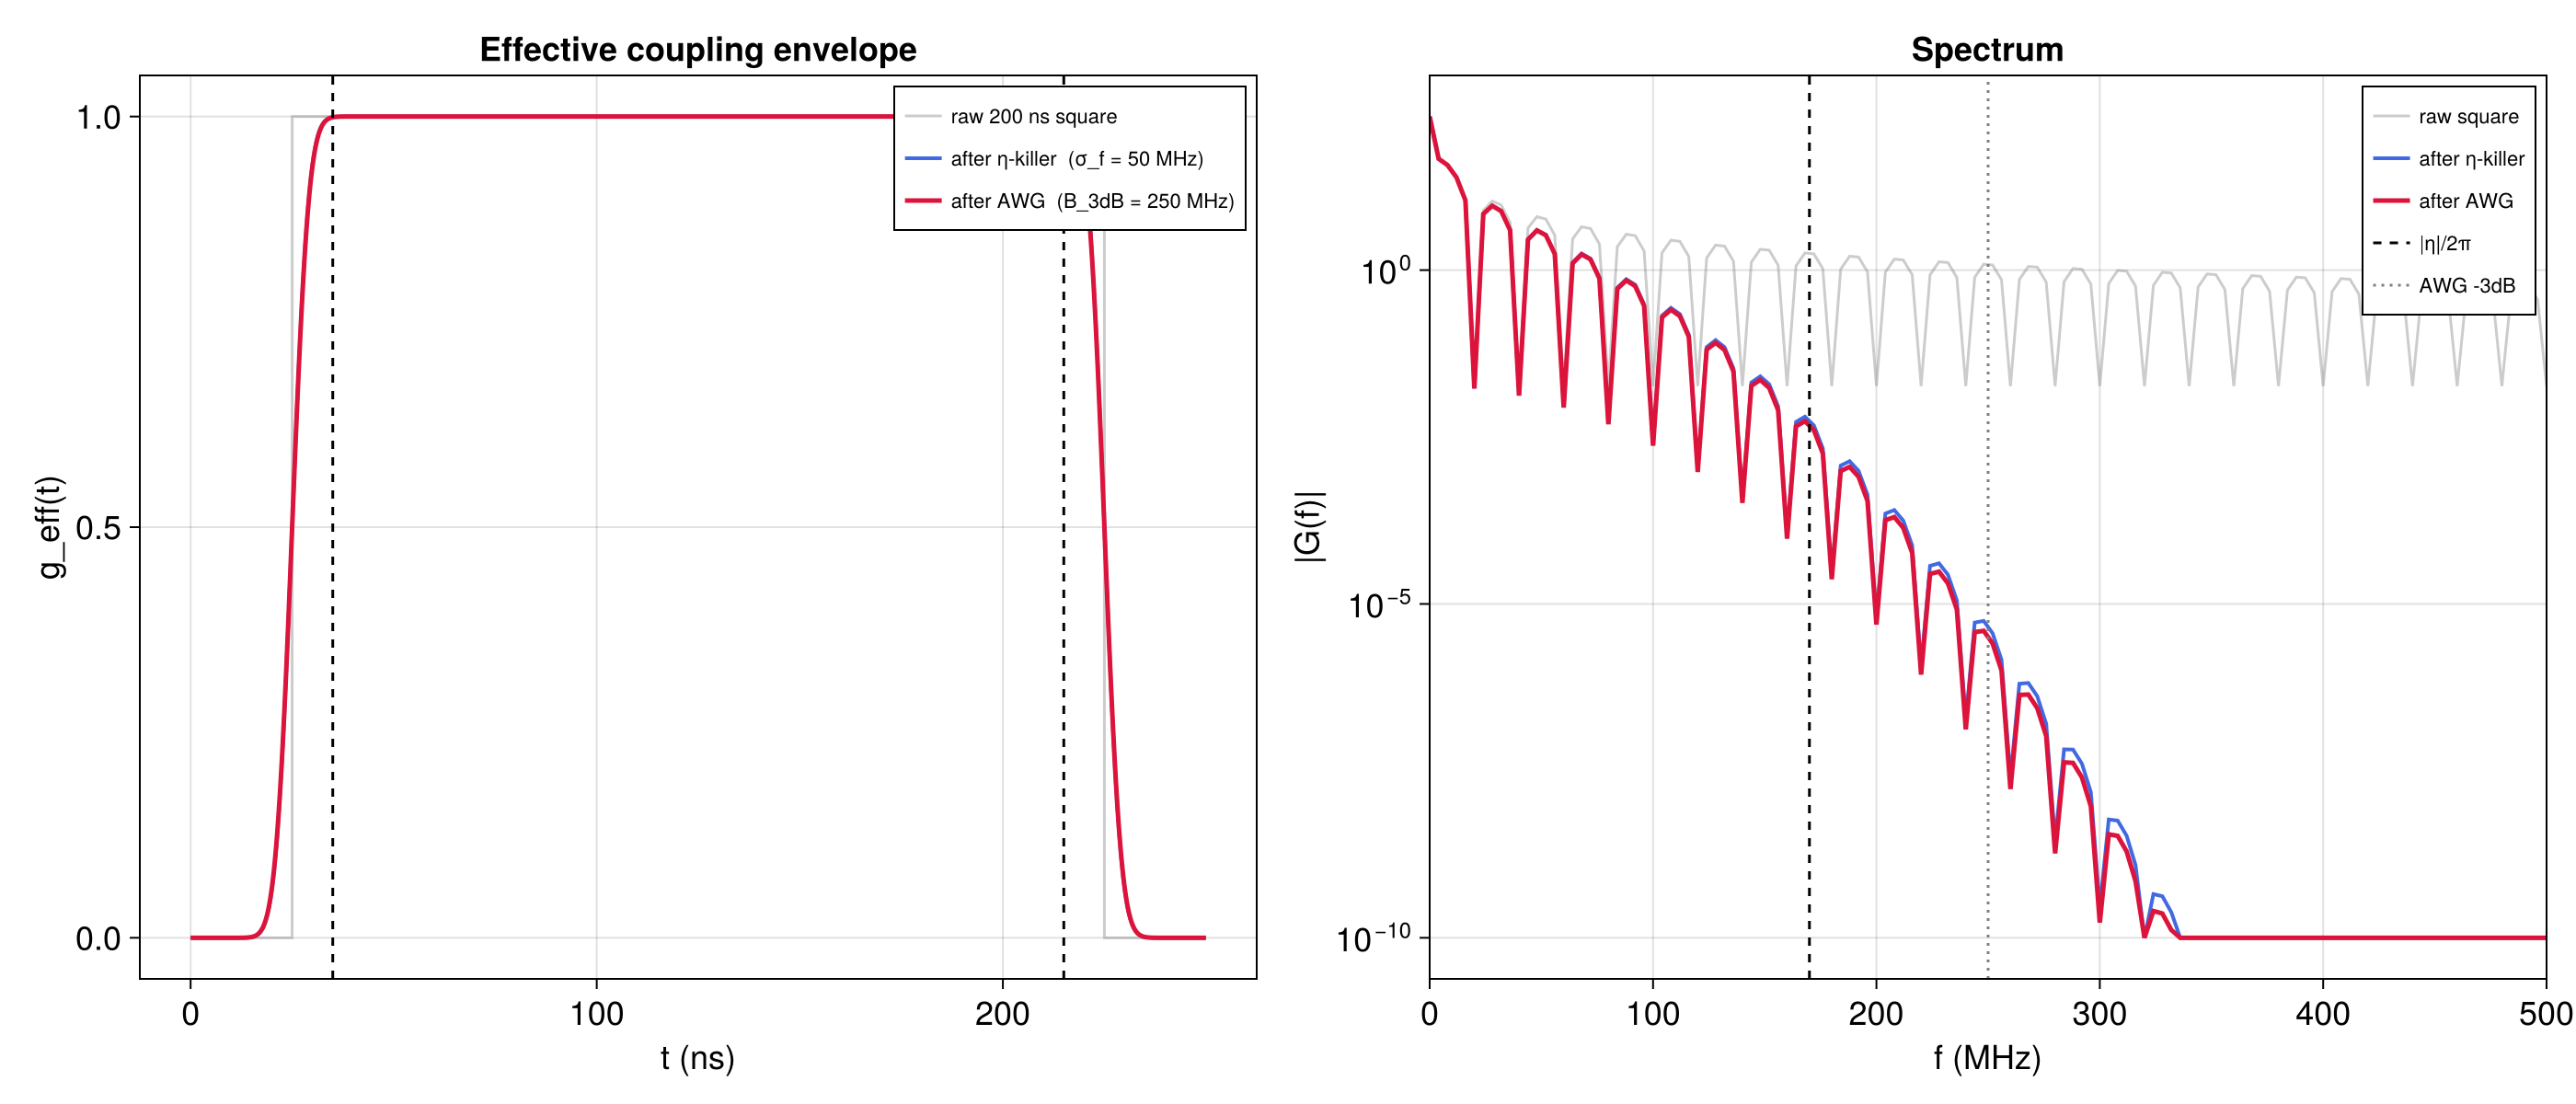

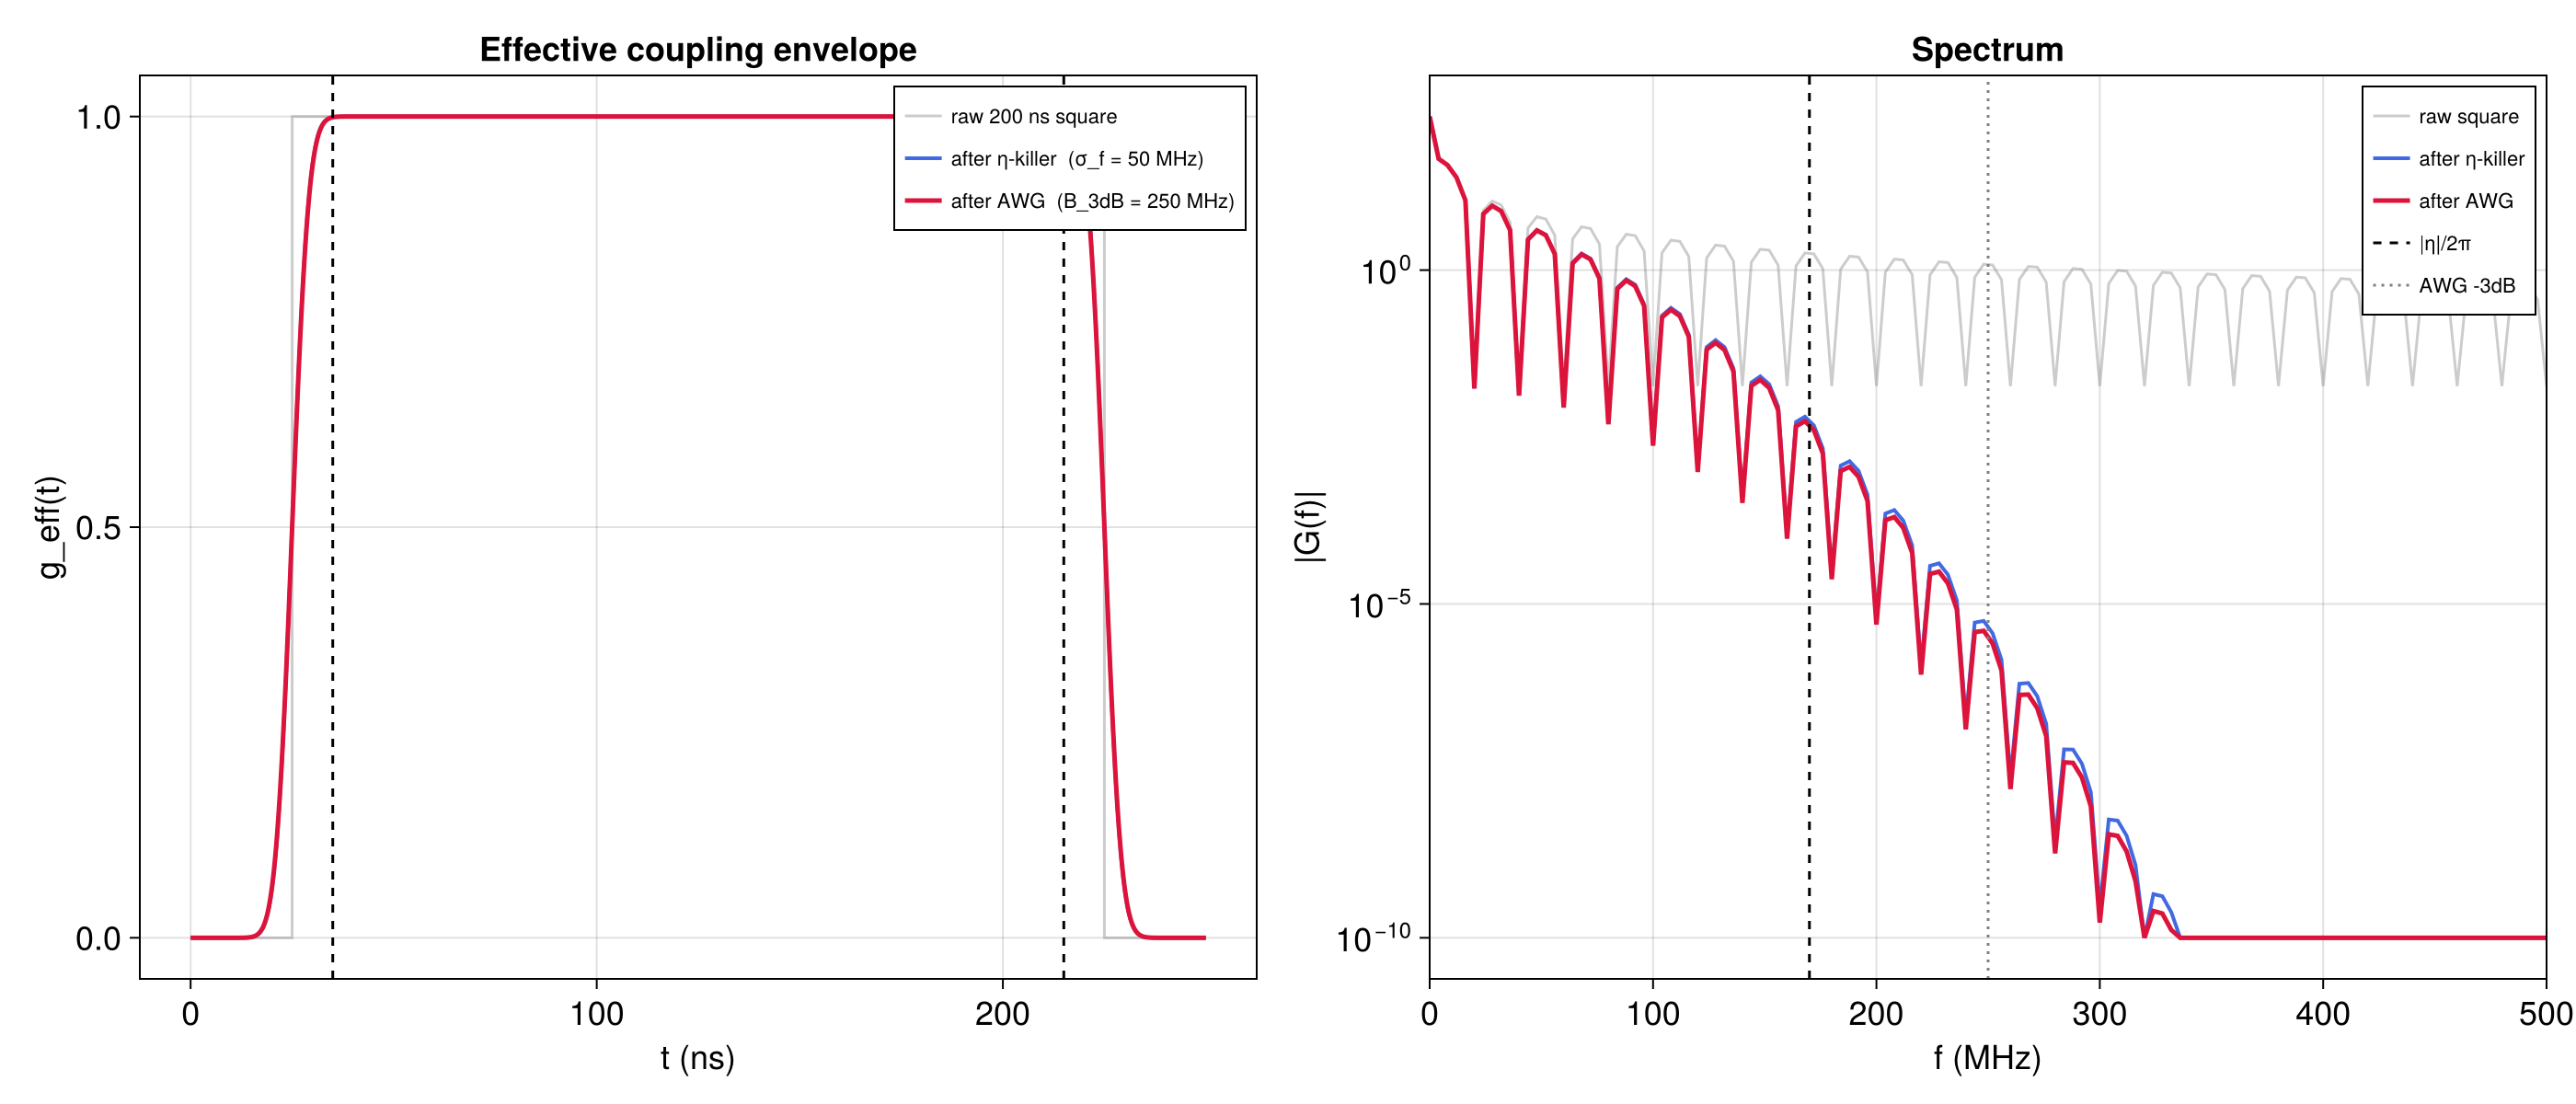

In [5]:
flat_start = T_RISE + T_EDGE_MARK
flat_end   = T_FALL - T_EDGE_MARK

fig = Figure(size = (1400, 600), fontsize = 18)

ax_t = Axis(fig[1, 1];
    xlabel = "t (ns)", ylabel = "g_eff(t)",
    title  = "Effective coupling envelope")
lines!(ax_t, ts, g_square;
    color = (:gray, 0.4), linewidth = 1.5, label = "raw 200 ns square")
lines!(ax_t, ts, g_after_anh;
    color = :royalblue, linewidth = 2.0,
    label = @sprintf("after η-killer  (σ_f = %.0f MHz)", σ_f_anh_MHz))
lines!(ax_t, ts, g_after_AWG;
    color = :crimson, linewidth = 2.5,
    label = @sprintf("after AWG  (B_3dB = %.0f MHz)", B_AWG_MHz))
vlines!(ax_t, [flat_start, flat_end];
    color = :black, linestyle = :dash, linewidth = 1.5)
axislegend(ax_t; position = :rt, labelsize = 11)

ax_f = Axis(fig[1, 2];
    xlabel = "f (MHz)", ylabel = "|G(f)|",
    yscale = log10, title = "Spectrum")
G_square    = abs.(fftshift(fft(g_square)))    .* dt_fine
G_after_anh = abs.(fftshift(fft(g_after_anh))) .* dt_fine
G_after_AWG = abs.(fftshift(fft(g_after_AWG))) .* dt_fine
fs_MHz_disp = fftshift(fftfreq(N_FINE, 1.0 / dt_fine)) .* 1e3
mask_pos    = fs_MHz_disp .≥ 0
lines!(ax_f, fs_MHz_disp[mask_pos], max.(G_square[mask_pos], 1e-10);
    color = (:gray, 0.4), linewidth = 1.5, label = "raw square")
lines!(ax_f, fs_MHz_disp[mask_pos], max.(G_after_anh[mask_pos], 1e-10);
    color = :royalblue, linewidth = 2.0, label = "after η-killer")
lines!(ax_f, fs_MHz_disp[mask_pos], max.(G_after_AWG[mask_pos], 1e-10);
    color = :crimson, linewidth = 2.5, label = "after AWG")
vlines!(ax_f, [η_MHz];
    color = :black, linestyle = :dash, linewidth = 1.5, label = "|η|/2π")
vlines!(ax_f, [B_AWG_MHz];
    color = :gray, linestyle = :dot,  linewidth = 1.5, label = "AWG -3dB")
xlims!(ax_f, 0, 500)
axislegend(ax_f; position = :rt, labelsize = 11)

save(joinpath(@__DIR__, "g_eff_filtered.png"), fig; px_per_unit = 4)
display(fig)
fig

## How much of the iSWAP is done at the dashed-line edges?

Convention (same as `modulate_iswap`): exchange Hamiltonian `H = g_eff(t)·(XX + YY)`. On the {|01⟩, |10⟩} swap subspace, `(XX+YY)` has eigenvalue ±2, so the Rabi rate is `2·g_eff` and **a full iSWAP requires `∫ g_eff(t) dt = π/4`**.

Set `g_max = 2 MHz` (peak amplitude). Then `cumul(t) / (π/4)` is the fraction of one full iSWAP accumulated by time `t`.

At `g_max = 2 MHz` with a 200 ns flat top, this pulse over-rotates significantly: `∫ g dt ≈ 2π·2 MHz · 200 ns ≈ 3.2·(π/4)`. The flat region carries most of that rotation as drift. We absorb the over-rotation via the V†·U_iSWAP·V† method (next section): the optimizer designs MW pulses that combine with the drift to produce `U_iSWAP` overall.

g_max = 2.00 MHz  (= 2π · 0.0020 rad/ns)
Total ∫ g_eff dt = 2.5130 rad = 3.200 · (π/4)   → pulse delivers 320.0% of one iSWAP

% of iSWAP done at t = T_RISE + 10 ns  =  16.02 %
% of iSWAP done at t = T_FALL  - 10 ns  = 303.98 %
% of iSWAP in the rising edge             =  16.02 %
% of iSWAP in the falling edge            =  15.99 %
% of iSWAP inside the flat region         = 287.96 %


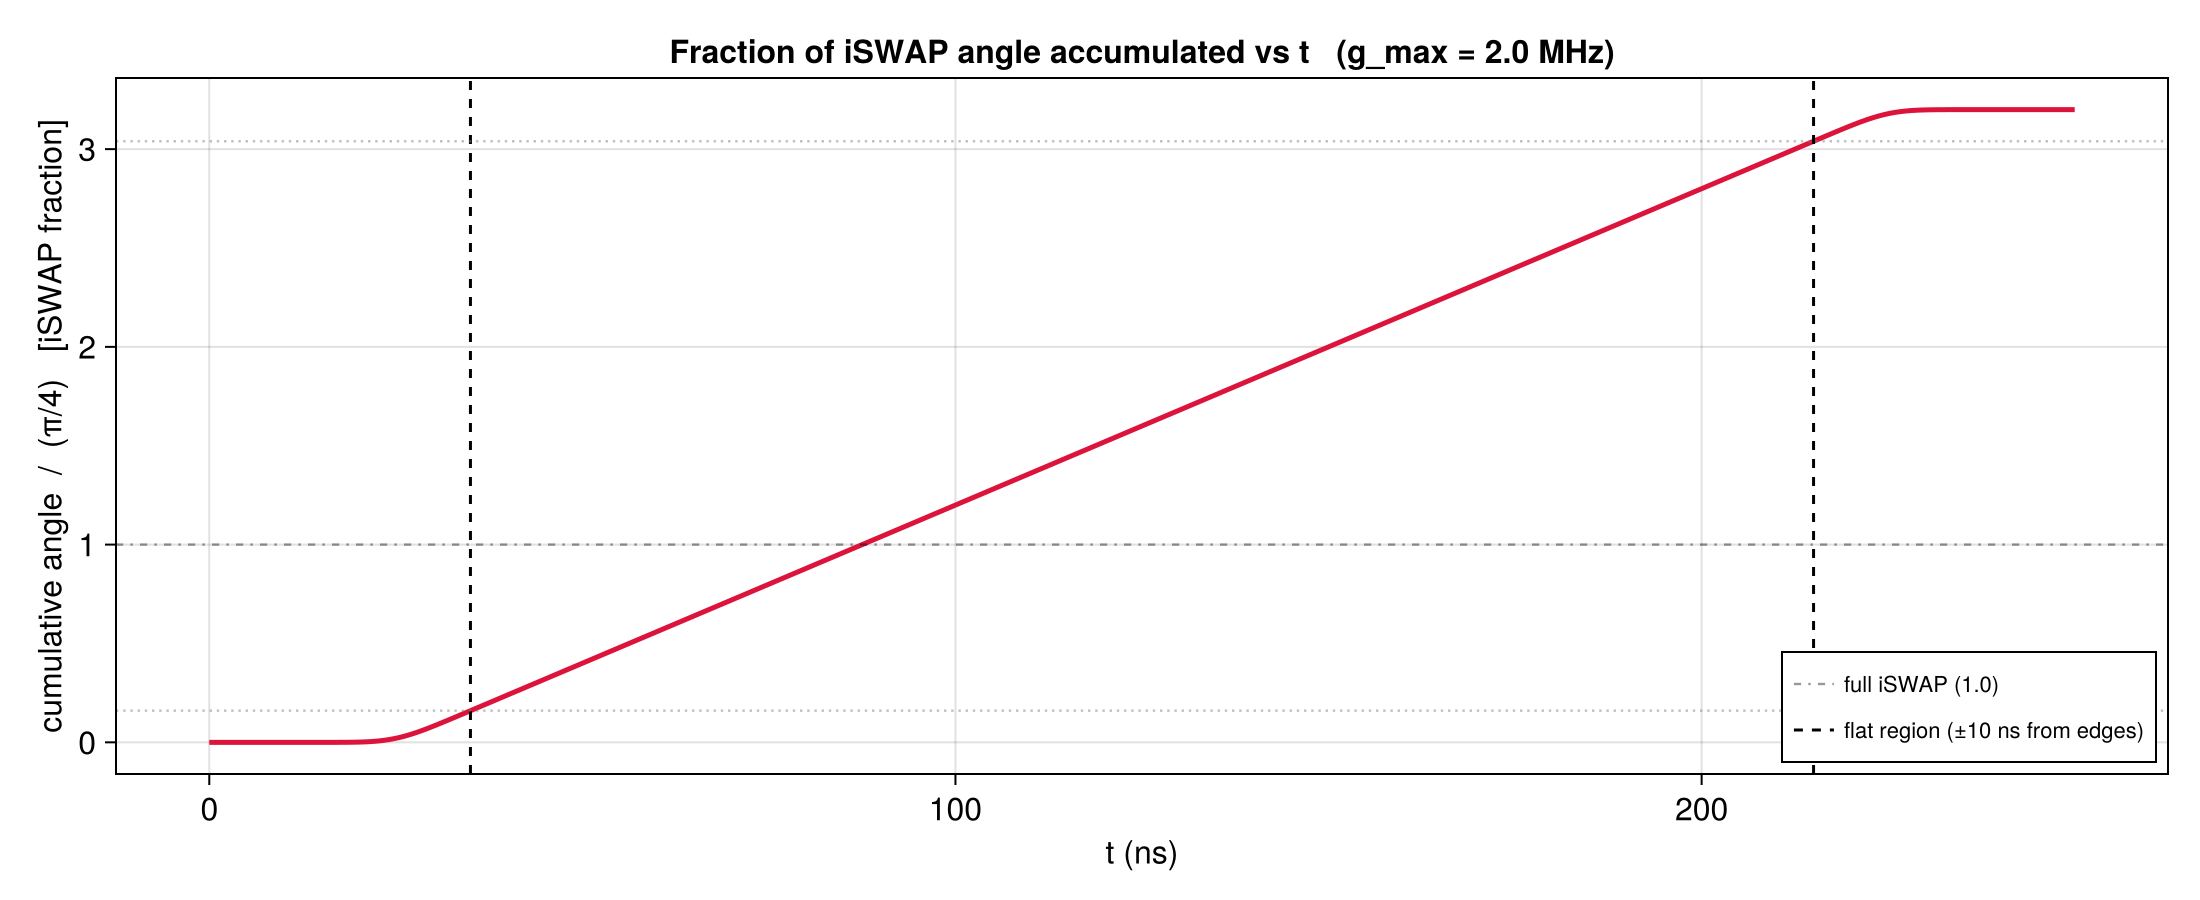

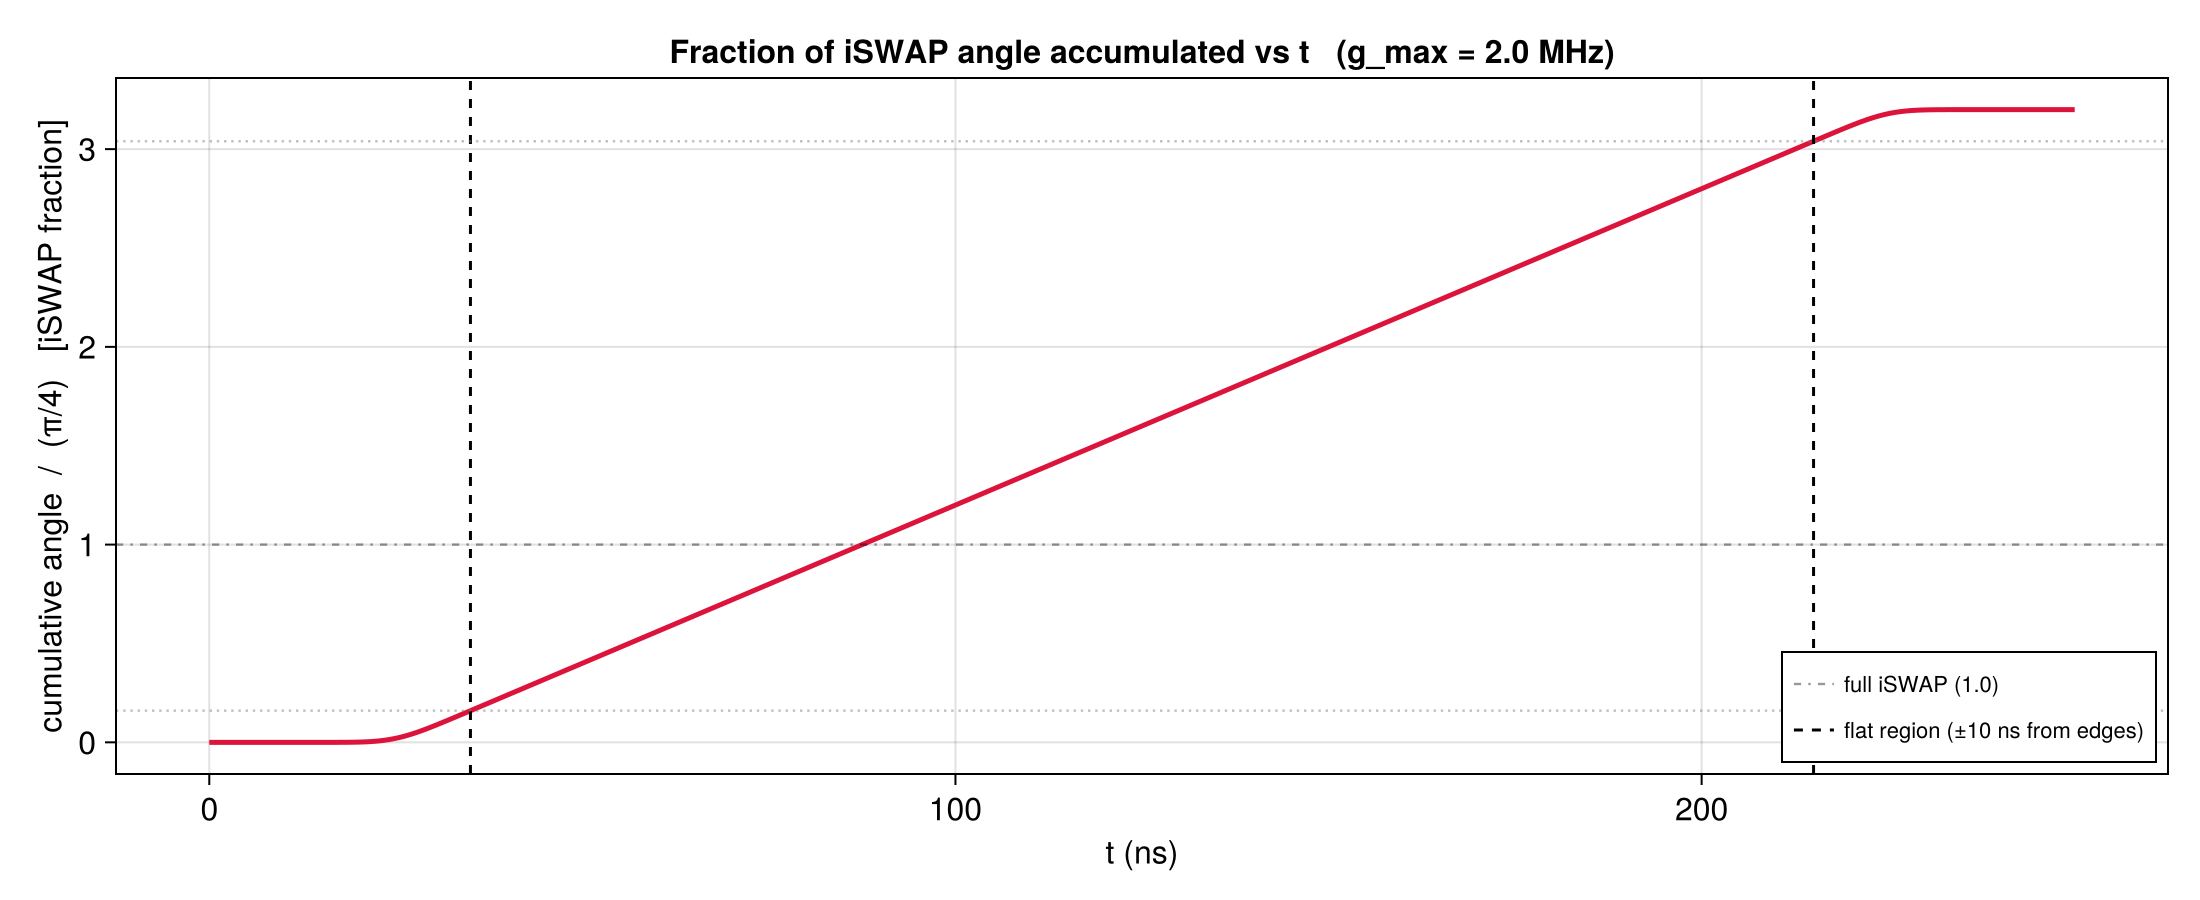

In [6]:
# Physical amplitude.  H = g_eff·(XX+YY), full iSWAP needs ∫ g_eff dt = π/4.

const g_max_MHz = 2.0
const g_max_rad_per_ns = 2π * g_max_MHz * 1e-3   # rad/ns

g_phys = g_after_AWG .* g_max_rad_per_ns         # rad/ns
cumul  = cumsum(g_phys) .* dt_fine               # rad
total_angle = cumul[end]                         # rad
n_iswaps    = total_angle / (π/4)                # full iSWAPs in the whole pulse

idx_flat_start = argmin(abs.(ts .- (T_RISE + T_EDGE_MARK)))
idx_flat_end   = argmin(abs.(ts .- (T_FALL - T_EDGE_MARK)))

pct_at_start = 100 * cumul[idx_flat_start] / (π/4)
pct_at_end   = 100 * cumul[idx_flat_end]   / (π/4)

@printf("g_max = %.2f MHz  (= 2π · %.4f rad/ns)\n", g_max_MHz, g_max_rad_per_ns / (2π))
@printf("Total ∫ g_eff dt = %.4f rad = %.3f · (π/4)   → pulse delivers %.1f%% of one iSWAP\n",
    total_angle, n_iswaps, 100 * n_iswaps)
@printf("\n")
@printf("%% of iSWAP done at t = T_RISE + %g ns  = %6.2f %%\n", T_EDGE_MARK, pct_at_start)
@printf("%% of iSWAP done at t = T_FALL  - %g ns  = %6.2f %%\n", T_EDGE_MARK, pct_at_end)
@printf("%% of iSWAP in the rising edge             = %6.2f %%\n", pct_at_start)
@printf("%% of iSWAP in the falling edge            = %6.2f %%\n", 100 * n_iswaps - pct_at_end)
@printf("%% of iSWAP inside the flat region         = %6.2f %%\n", pct_at_end - pct_at_start)

fig2 = Figure(size = (1100, 450), fontsize = 16)
ax = Axis(fig2[1, 1];
    xlabel = "t (ns)",
    ylabel = "cumulative angle  /  (π/4)   [iSWAP fraction]",
    title  = @sprintf("Fraction of iSWAP angle accumulated vs t   (g_max = %.1f MHz)", g_max_MHz))
lines!(ax, ts, cumul ./ (π/4); color = :crimson, linewidth = 2.5)
hlines!(ax, [1.0]; color = (:black, 0.4), linestyle = :dashdot, linewidth = 1.2,
    label = "full iSWAP (1.0)")
vlines!(ax, [T_RISE + T_EDGE_MARK, T_FALL - T_EDGE_MARK];
    color = :black, linestyle = :dash, linewidth = 1.5,
    label = @sprintf("flat region (±%g ns from edges)", T_EDGE_MARK))
hlines!(ax, [pct_at_start / 100, pct_at_end / 100];
    color = (:gray, 0.5), linestyle = :dot, linewidth = 1.2)
axislegend(ax; position = :rb, labelsize = 11)
save(joinpath(@__DIR__, "g_eff_iswap_fraction.png"), fig2; px_per_unit = 4)
display(fig2)
fig2

## Edge unitaries V_rise, V_fall and the flat-region target U_goal

During the rising and falling edges of the filtered g_eff, the only physics active is the drift `g_eff(t)·(XX+YY)` (microwaves are off). Since `(XX+YY)` commutes with itself at all times, these edges are pure (XX+YY) rotations:

  `V_rise = exp(-i · A_rise · (XX+YY))`
  `V_fall = exp(-i · A_fall · (XX+YY))`

with `A_rise = ∫_0^{T_RISE+10} g_eff(t) dt` and `A_fall = ∫_{T_FALL-10}^{T_TOTAL} g_eff(t) dt`.

We want `V_fall · U_flat · V_rise = U_iSWAP`, so the flat-region optimizer should produce:

  `U_goal = V_fall† · U_iSWAP · V_rise†`

All three V's commute with each other (same generator), so this collapses to `U_goal = exp(-i·(π/4 − A_rise − A_fall)·(XX+YY))`. The flat-region drift will still be active during the optimization, so the MW pulses don't directly produce this — they shape the (drift+MW) dynamics so that the full flat-region unitary equals `U_goal`.

In [7]:
# Pauli operators on 4-dim space
const XX = operator_from_string("XX")
const YY = operator_from_string("YY")
const XI = operator_from_string("XI")
const YI = operator_from_string("YI")
const IX = operator_from_string("IX")
const IY = operator_from_string("IY")
const ZI = operator_from_string("ZI")
const IZ = operator_from_string("IZ")
const ZZ = operator_from_string("ZZ")

# Edge areas from the filtered envelope
A_rise = cumul[idx_flat_start]
A_fall = cumul[end] - cumul[idx_flat_end]
A_flat_drift = cumul[idx_flat_end] - cumul[idx_flat_start]

@printf("A_rise        = %.4f rad  = %.2f%% of (π/4)\n", A_rise, 100*A_rise/(π/4))
@printf("A_fall        = %.4f rad  = %.2f%% of (π/4)\n", A_fall, 100*A_fall/(π/4))
@printf("A_flat_drift  = %.4f rad  = %.2f%% of (π/4)\n", A_flat_drift, 100*A_flat_drift/(π/4))
@printf("sum           = %.4f rad  = %.2f%% of (π/4)\n",
    A_rise + A_flat_drift + A_fall, 100*(A_rise + A_flat_drift + A_fall)/(π/4))

V_rise   = exp(-im * A_rise * (XX + YY))
V_fall   = exp(-im * A_fall * (XX + YY))
U_iSWAP  = exp(-im * (π/4) * (XX + YY))
U_goal   = V_fall' * U_iSWAP * V_rise'

# Sanity check: V_fall · U_goal · V_rise should reproduce U_iSWAP exactly
F_check = abs2(tr(U_iSWAP' * (V_fall * U_goal * V_rise))) / 16
@printf("\nF(V_fall · U_goal · V_rise, iSWAP) = %.10f\n", F_check)

A_rise        = 0.1258 rad  = 16.02% of (π/4)
A_fall        = 0.1256 rad  = 15.99% of (π/4)
A_flat_drift  = 2.2616 rad  = 287.96% of (π/4)
sum           = 2.5130 rad  = 319.97% of (π/4)

F(V_fall · U_goal · V_rise, iSWAP) = 1.0000000000


## Per-qubit spectral leakage constraint

Same physics as the 1Q `SpectralLeakageConstraint` — but now applied to *each qubit's* (u_X, u_Y) IQ pair within the 4-channel control vector. We constrain `|Ω_i(η)|² ≤ ε_max` separately for qubit 1 (channels 1, 2) and qubit 2 (channels 3, 4).

In [8]:
# 2Q-friendly spectral leakage constraint: selects two channels (i_X, i_Y) of a wider :u.
# Identical to the 1Q SpectralLeakageConstraint in functional form.

struct SpectralLeakageConstraintIQ <: AbstractNonlinearConstraint
    name::Symbol
    i_X::Int
    i_Y::Int
    ω::Float64
    ε_max::Float64
    times_t::Vector{Float64}
    Δts::Vector{Float64}
    cosωt::Vector{Float64}
    sinωt::Vector{Float64}
    dim::Int
    equality::Bool
end

function SpectralLeakageConstraintIQ(name::Symbol, i_X::Int, i_Y::Int,
                                     ω::Float64, ε_max::Float64, traj)
    times = get_times(traj)
    Δts   = get_timesteps(traj)
    return SpectralLeakageConstraintIQ(name, i_X, i_Y, ω, ε_max,
        Vector{Float64}(times), Vector{Float64}(Δts),
        cos.(ω .* times), sin.(ω .* times),
        1, false)
end

function _ReIm_IQ(c::SpectralLeakageConstraintIQ, u::AbstractMatrix)
    Re_sum = zero(eltype(u))
    Im_sum = zero(eltype(u))
    @inbounds for k in 1:length(c.times_t)
        cos_k = c.cosωt[k]; sin_k = c.sinωt[k]; Δt_k = c.Δts[k]
        uX = u[c.i_X, k]; uY = u[c.i_Y, k]
        Re_sum += Δt_k * (uX * cos_k + uY * sin_k)
        Im_sum += Δt_k * (uY * cos_k - uX * sin_k)
    end
    return Re_sum, Im_sum
end

function CommonInterface.evaluate!(values::AbstractVector,
                                   c::SpectralLeakageConstraintIQ, traj)
    u = traj[c.name]
    Re_sum, Im_sum = _ReIm_IQ(c, u)
    values[1] = Re_sum^2 + Im_sum^2 - c.ε_max
    return nothing
end

function CommonInterface.eval_jacobian(c::SpectralLeakageConstraintIQ, traj)
    Z_dim = traj.dim * traj.N + traj.global_dim
    ∂g    = spzeros(c.dim, Z_dim)
    u     = traj[c.name]
    Re_sum, Im_sum = _ReIm_IQ(c, u)
    comps = traj.components[c.name]
    @inbounds for k in 1:traj.N
        cos_k = c.cosωt[k]; sin_k = c.sinωt[k]; Δt_k = c.Δts[k]
        idxX = traj.dim * (k - 1) + comps[c.i_X]
        idxY = traj.dim * (k - 1) + comps[c.i_Y]
        ∂g[1, idxX] = 2 * Δt_k * (Re_sum * cos_k - Im_sum * sin_k)
        ∂g[1, idxY] = 2 * Δt_k * (Re_sum * sin_k + Im_sum * cos_k)
    end
    return ∂g
end

function CommonInterface.eval_hessian_of_lagrangian(c::SpectralLeakageConstraintIQ,
                                                    traj, μ::AbstractVector)
    Z_dim = traj.dim * traj.N + traj.global_dim
    ∂²g   = spzeros(Z_dim, Z_dim)
    comps = traj.components[c.name]
    a = zeros(Z_dim); b = zeros(Z_dim)
    @inbounds for k in 1:traj.N
        idxX = traj.dim * (k - 1) + comps[c.i_X]
        idxY = traj.dim * (k - 1) + comps[c.i_Y]
        a[idxX] = c.Δts[k] * c.cosωt[k]
        a[idxY] = c.Δts[k] * c.sinωt[k]
        b[idxX] = -c.Δts[k] * c.sinωt[k]
        b[idxY] =  c.Δts[k] * c.cosωt[k]
    end
    nzs = findall(!iszero, a) ∪ findall(!iszero, b)
    for i in nzs, j in nzs
        v = 2 * μ[1] * (a[i]*a[j] + b[i]*b[j])
        if v != 0.0
            ∂²g[i, j] = v
        end
    end
    return ∂²g
end

println("SpectralLeakageConstraintIQ defined.")

SpectralLeakageConstraintIQ defined.


## Flat-region optimization problem

- **Hilbert space**: 4-dim (two 2-lvl qubits).
- **Drift**: `g_flat · (XX+YY)` where `g_flat = g_max` (the filtered envelope is essentially flat in this region; we approximate it as constant).
- **Controls**: 4 channels `[u_X1, u_Y1, u_X2, u_Y2]`, bounded at `a_bound_MW = 2π·10 MHz`. On-resonance with each qubit (no carrier detuning since both qubits share `ω` for the iSWAP — adjust if you want detuned drives).
- **Spline**: 15 knots over the 180 ns flat region (`Δt = 12 ns`).
- **Target**: `U_goal` (computed above).
- **Fidelity constraint**: `F ≥ 0.9999`.
- **Spectral leakage constraint**: `|Ω̂_i(2π·170 MHz)|² ≤ 1e-2` for each qubit `i ∈ {1, 2}`.
- **Robustness**: variational sensitivity against `ZI` and `IZ` (per-qubit σ_z dephasing). `Q_r = 1e2`.

In [9]:
# Flat-region Hamiltonian
const g_flat        = g_max_rad_per_ns          # rad/ns (drift inside flat region)
const a_bound_MW    = 2π * 0.01                  # 10 MHz MW amplitude bound
const F_THRESHOLD   = 0.9999
const Q_R           = 1e2
const ε_MAX         = 1e-2
const N_KNOTS       = 15
const N_SAMPLES_OPT = 300
const T_FLAT_NS     = T_FALL - T_RISE - 2 * T_EDGE_MARK     # 180 ns
const Δt_FLAT       = T_FLAT_NS / (N_KNOTS - 1)
const η_rad_per_ns  = 2π * η_MHz * 1e-3          # 2π · 170 MHz in rad/ns

# On-resonant drives (Δ_mw = 0)
function H_flat_gate(u, t)
    H = g_flat * (XX + YY)
    H += u[1] * XI + u[2] * YI
    H += u[3] * IX + u[4] * IY
    return H
end

# Variational error generators
H_vars = Function[
    (u, t) -> ZI,
    (u, t) -> IZ,
    (u, t) -> ZZ,
]

drive_bounds = fill(a_bound_MW, 4)

varsys = VariationalQuantumSystem(
    H_flat_gate, H_vars, 4, drive_bounds;
    time_dependent = true,
)

println("VariationalQuantumSystem built.")
println("  levels = ", varsys.levels, "   n_drives = ", varsys.n_drives,
    "   n_vars = ", length(varsys.G_vars))

VariationalQuantumSystem built.
  levels = 4   n_drives = 4   n_vars = 3


In [10]:
Random.seed!(42)
controls_init = 2 .* a_bound_MW .* rand(4, N_SAMPLES_OPT) .- a_bound_MW
times_init    = collect(LinRange(0.0, T_FLAT_NS, N_SAMPLES_OPT))
du_init       = zeros(4, N_SAMPLES_OPT)
pulse_init    = CubicSplinePulse(controls_init, du_init, times_init)

qcp = VariationalSplinePulseProblem(
    varsys, pulse_init, U_goal, N_KNOTS;
    Q                     = 0.0,
    Q_r                   = Q_R,
    R                     = 1e-3,
    du_bound              = Inf,
    Δt_bounds             = (Δt_FLAT, Δt_FLAT),
    dynamics_spline_order = 3,
    n_path_samples        = 3,
)

# Fidelity constraint
push!(qcp.prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_THRESHOLD, get_trajectory(qcp))
)

# Spectral leakage constraints — one per qubit's (u_X, u_Y) pair at ω = 2π·170 MHz
traj = get_trajectory(qcp)
push!(qcp.prob.constraints,
    SpectralLeakageConstraintIQ(:u, 1, 2, η_rad_per_ns, ε_MAX, traj)
)
push!(qcp.prob.constraints,
    SpectralLeakageConstraintIQ(:u, 3, 4, η_rad_per_ns, ε_MAX, traj)
)

@printf("\nProblem built.\n")
@printf("  Flat-region duration : %.1f ns\n", T_FLAT_NS)
@printf("  Spline knots          : %d   (Δt = %.2f ns)\n", N_KNOTS, Δt_FLAT)
@printf("  Spectral notch        : ω = 2π · %.1f MHz,  ε_max = %.0e  (per qubit)\n",
    η_MHz, ε_MAX)
@printf("  Fidelity threshold    : %.4f\n", F_THRESHOLD)
@printf("  Q_r (ZI, IZ)          : %.0e\n", Q_R)

    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{DataInterpolations.CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 3
      added augmented state :var_Ũ⃗  dim=128  (3 error channels)
      dynamics spline order: 3
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283

Problem built.
  Flat-region duration : 180.0 ns
  Spline knots          : 15   (Δt = 12.86 ns)
  Spectral notch        : ω = 2π · 170.0 MHz,  ε_max = 1e-02  (per qubit)
  Fidelity threshold    : 0.9999
  Q_r (ZI, IZ)          : 1e+02


## Solve

Uncomment to run. Expect several minutes for 500 iter on 4-dim. Save the trajectory afterward.

In [11]:
using JLD2

const RUN_TAG = "robust_2lvl_4dim_geff2MHz_200ns_eta170"
const IPOPT_LOG = joinpath(@__DIR__, "ipopt_$(RUN_TAG).log")
const TRAJ_PATH = joinpath(@__DIR__, "traj_$(RUN_TAG).jld2")

println("Solving 2-lvl 4-dim robust iSWAP optimization...")
println("  IPOPT log: $IPOPT_LOG")
println("  Trajectory: $TRAJ_PATH")

t0 = time()
solve!(qcp; max_iter = 1000, print_level = 5,
    options = IpoptOptions(
        eval_hessian    = false,
        output_file     = IPOPT_LOG,
        constr_viol_tol = 1e-8,
        tol             = 1e-8,
        acceptable_tol  = 1e-8,
    ))
@printf("solve wall: %.1f s\n", time() - t0)

traj_robust = get_trajectory(qcp)
U_flat_final = iso_vec_to_operator(traj_robust[:Ũ⃗][:, end])
F_flat       = abs2(tr(U_goal' * U_flat_final)) / 16
U_full       = V_fall * U_flat_final * V_rise
F_full       = abs2(tr(U_iSWAP' * U_full)) / 16

@printf("\nF(U_flat, U_goal)            = %.8f   (1−F = %.3e)\n", F_flat, 1 - F_flat)
@printf("F(V_fall·U_flat·V_rise, iSWAP) = %.8f   (1−F = %.3e)\n", F_full, 1 - F_full)

# Save trajectory + key metadata for later warm-start polish
@save TRAJ_PATH traj_robust U_goal U_iSWAP V_rise V_fall A_rise A_fall A_flat_drift g_max_MHz η_MHz T_FLAT_NS T_RISE T_FALL T_EDGE_MARK
println("Saved.")

Solving 2-lvl 4-dim robust iSWAP optimization...
  IPOPT log: /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational/ipopt_robust_2lvl_4dim_geff2MHz_200ns_eta170.log
  Trajectory: /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational/traj_robust_2lvl_4dim_geff2MHz_200ns_eta170.jld2
    initializing optimizer...
      building evaluator: 2 integrators, 4 nonlinear constraints
      dynamics constraints: 2240, nonlinear constraints: 339
        integrator 1 jacobian structure: 0.113s
        integrator 2 jacobian structure: 0.032s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.523s
        constraint 2 (NonlinearKnotPointConstraint) jacobian structure: 0.57s
        constraint 3 (SpectralLeakageConstraintIQ) jacobian structure: 0.021s
        constraint 4 (SpectralLeakageConstraintIQ) jacobian structure: 0.015s
 

## Default baseline (filtered Gaussian-square only, no MW)

Reference: H4 in *Modular Quantum Processor with an All-to-All Reconfigurable Router* — the calibration form

  `U_iSWAP_paper = diag(1, 0, 0, 0; 0, 0, −i·e^{i α_2}, 0; 0, −i·e^{i α_1}, 0, 0; 0, 0, 0, e^{i(θ_zz + α_1 + α_2)})`

(δ₀ = 0 for on-resonance qubits, so the `δ_0·t_b` terms drop.) The free parameters `(α_1, α_2, θ_zz)` are virtual single-qubit Z phases on each qubit and a virtual ZZ phase — all implementable as frame changes after the gate.

Default-case fidelity = max over `(α_1, α_2, θ_zz)` of `|Tr(U_iSWAP_paper† · U_default)|² / 16`, where `U_default` is the drift-only propagator (no microwaves).

In [12]:
# Virtual single-qubit Z corrections only (α₁, α₂) — pure frame change, free in hardware.
# No θ_zz: a virtual ZZ is NOT a free frame change.

function virtual_corrected_fidelity_Zonly(U_actual::AbstractMatrix; n_grid::Int = 400)
    @assert size(U_actual) == (4, 4)
    a = U_actual[1, 1]
    b = im * U_actual[3, 2]
    c = im * U_actual[2, 3]
    d = U_actual[4, 4]
    best_F  = 0.0
    best_α1 = 0.0; best_α2 = 0.0
    α_grid  = collect(LinRange(-π, π, n_grid + 1))[1:end-1]
    @inbounds for α1 in α_grid, α2 in α_grid
        z = a + b * exp(-im * α1) + c * exp(-im * α2)
        w = d * exp(-im * (α1 + α2))
        F = abs2(z + w) / 16
        if F > best_F
            best_F = F; best_α1 = α1; best_α2 = α2
        end
    end
    return best_F, (best_α1, best_α2)
end

println("virtual_corrected_fidelity_Zonly ready (no ZZ correction).")

virtual_corrected_fidelity_Zonly ready (no ZZ correction).


## Default case: drift-only propagation

Integrate `H = g_eff(t) · (XX+YY)` over the full 250 ns window (no microwaves) using the filtered envelope. Report F to `U_iSWAP` raw and after virtual-Z+ZZ correction.

In [13]:
# Drift-only propagation of the *unaltered* 200 ns filtered envelope (over-rotates).
# Reported for diagnostic only — the actual baseline is the calibrated default below.

function propagate_drift_4dim(g_phys_vec::AbstractVector, ts_vec::AbstractVector)
    U = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_vec) - 1)
        dt_k = ts_vec[k+1] - ts_vec[k]
        g_mid = 0.5 * (g_phys_vec[k] + g_phys_vec[k+1])
        U = exp(-im * dt_k * g_mid * (XX + YY)) * U
    end
    return U
end

U_overrot = propagate_drift_4dim(g_phys, ts)
F_overrot_raw = abs2(tr(U_iSWAP' * U_overrot)) / 16
F_overrot_vc, (α1_o, α2_o) = virtual_corrected_fidelity_Zonly(U_overrot)

@printf("=== Drift-only, 200 ns over-rotated envelope (no MW) ===\n")
@printf("F_raw                  = %.6f   (1−F = %.3e)\n", F_overrot_raw, 1 - F_overrot_raw)
@printf("F after virtual Z₁,Z₂   = %.6f   (1−F = %.3e)\n", F_overrot_vc,  1 - F_overrot_vc)
@printf("  best (α₁, α₂) = (%+.4f, %+.4f) rad\n", α1_o, α2_o)

=== Drift-only, 200 ns over-rotated envelope (no MW) ===
F_raw                  = 0.000598   (1−F = 9.994e-01)
F after virtual Z₁,Z₂   = 0.951702   (1−F = 4.830e-02)
  best (α₁, α₂) = (-3.1416, -3.1416) rad


## Optimized case: full gate (edges + flat-region MW)

In [14]:
U_flat_opt = iso_vec_to_operator(traj_robust[:Ũ⃗][:, end])
U_full_opt = V_fall * U_flat_opt * V_rise

F_opt_raw = abs2(tr(U_iSWAP' * U_full_opt)) / 16
F_opt_vc, (α1_o, α2_o) = virtual_corrected_fidelity_Zonly(U_full_opt)

@printf("=== Optimized (full gate, V_fall · U_flat · V_rise) ===\n")
@printf("F_raw                  = %.8f   (1−F = %.3e)\n", F_opt_raw, 1 - F_opt_raw)
@printf("F after virtual Z₁,Z₂   = %.8f   (1−F = %.3e)\n", F_opt_vc,  1 - F_opt_vc)
@printf("  best (α₁, α₂) = (%+.4f, %+.4f) rad\n", α1_o, α2_o)

=== Optimized (full gate, V_fall · U_flat · V_rise) ===
F_raw                  = 0.99990232   (1−F = 9.768e-05)
F after virtual Z₁,Z₂   = 0.99990232   (1−F = 9.768e-05)
  best (α₁, α₂) = (+0.0000, +0.0000) rad


## Full pulse plot: g_eff(t) + 4 MW channels

Same convention as `modulate_iswap`: knots as dots, fine sample as line. Microwaves only exist inside the flat region; outside is zero.

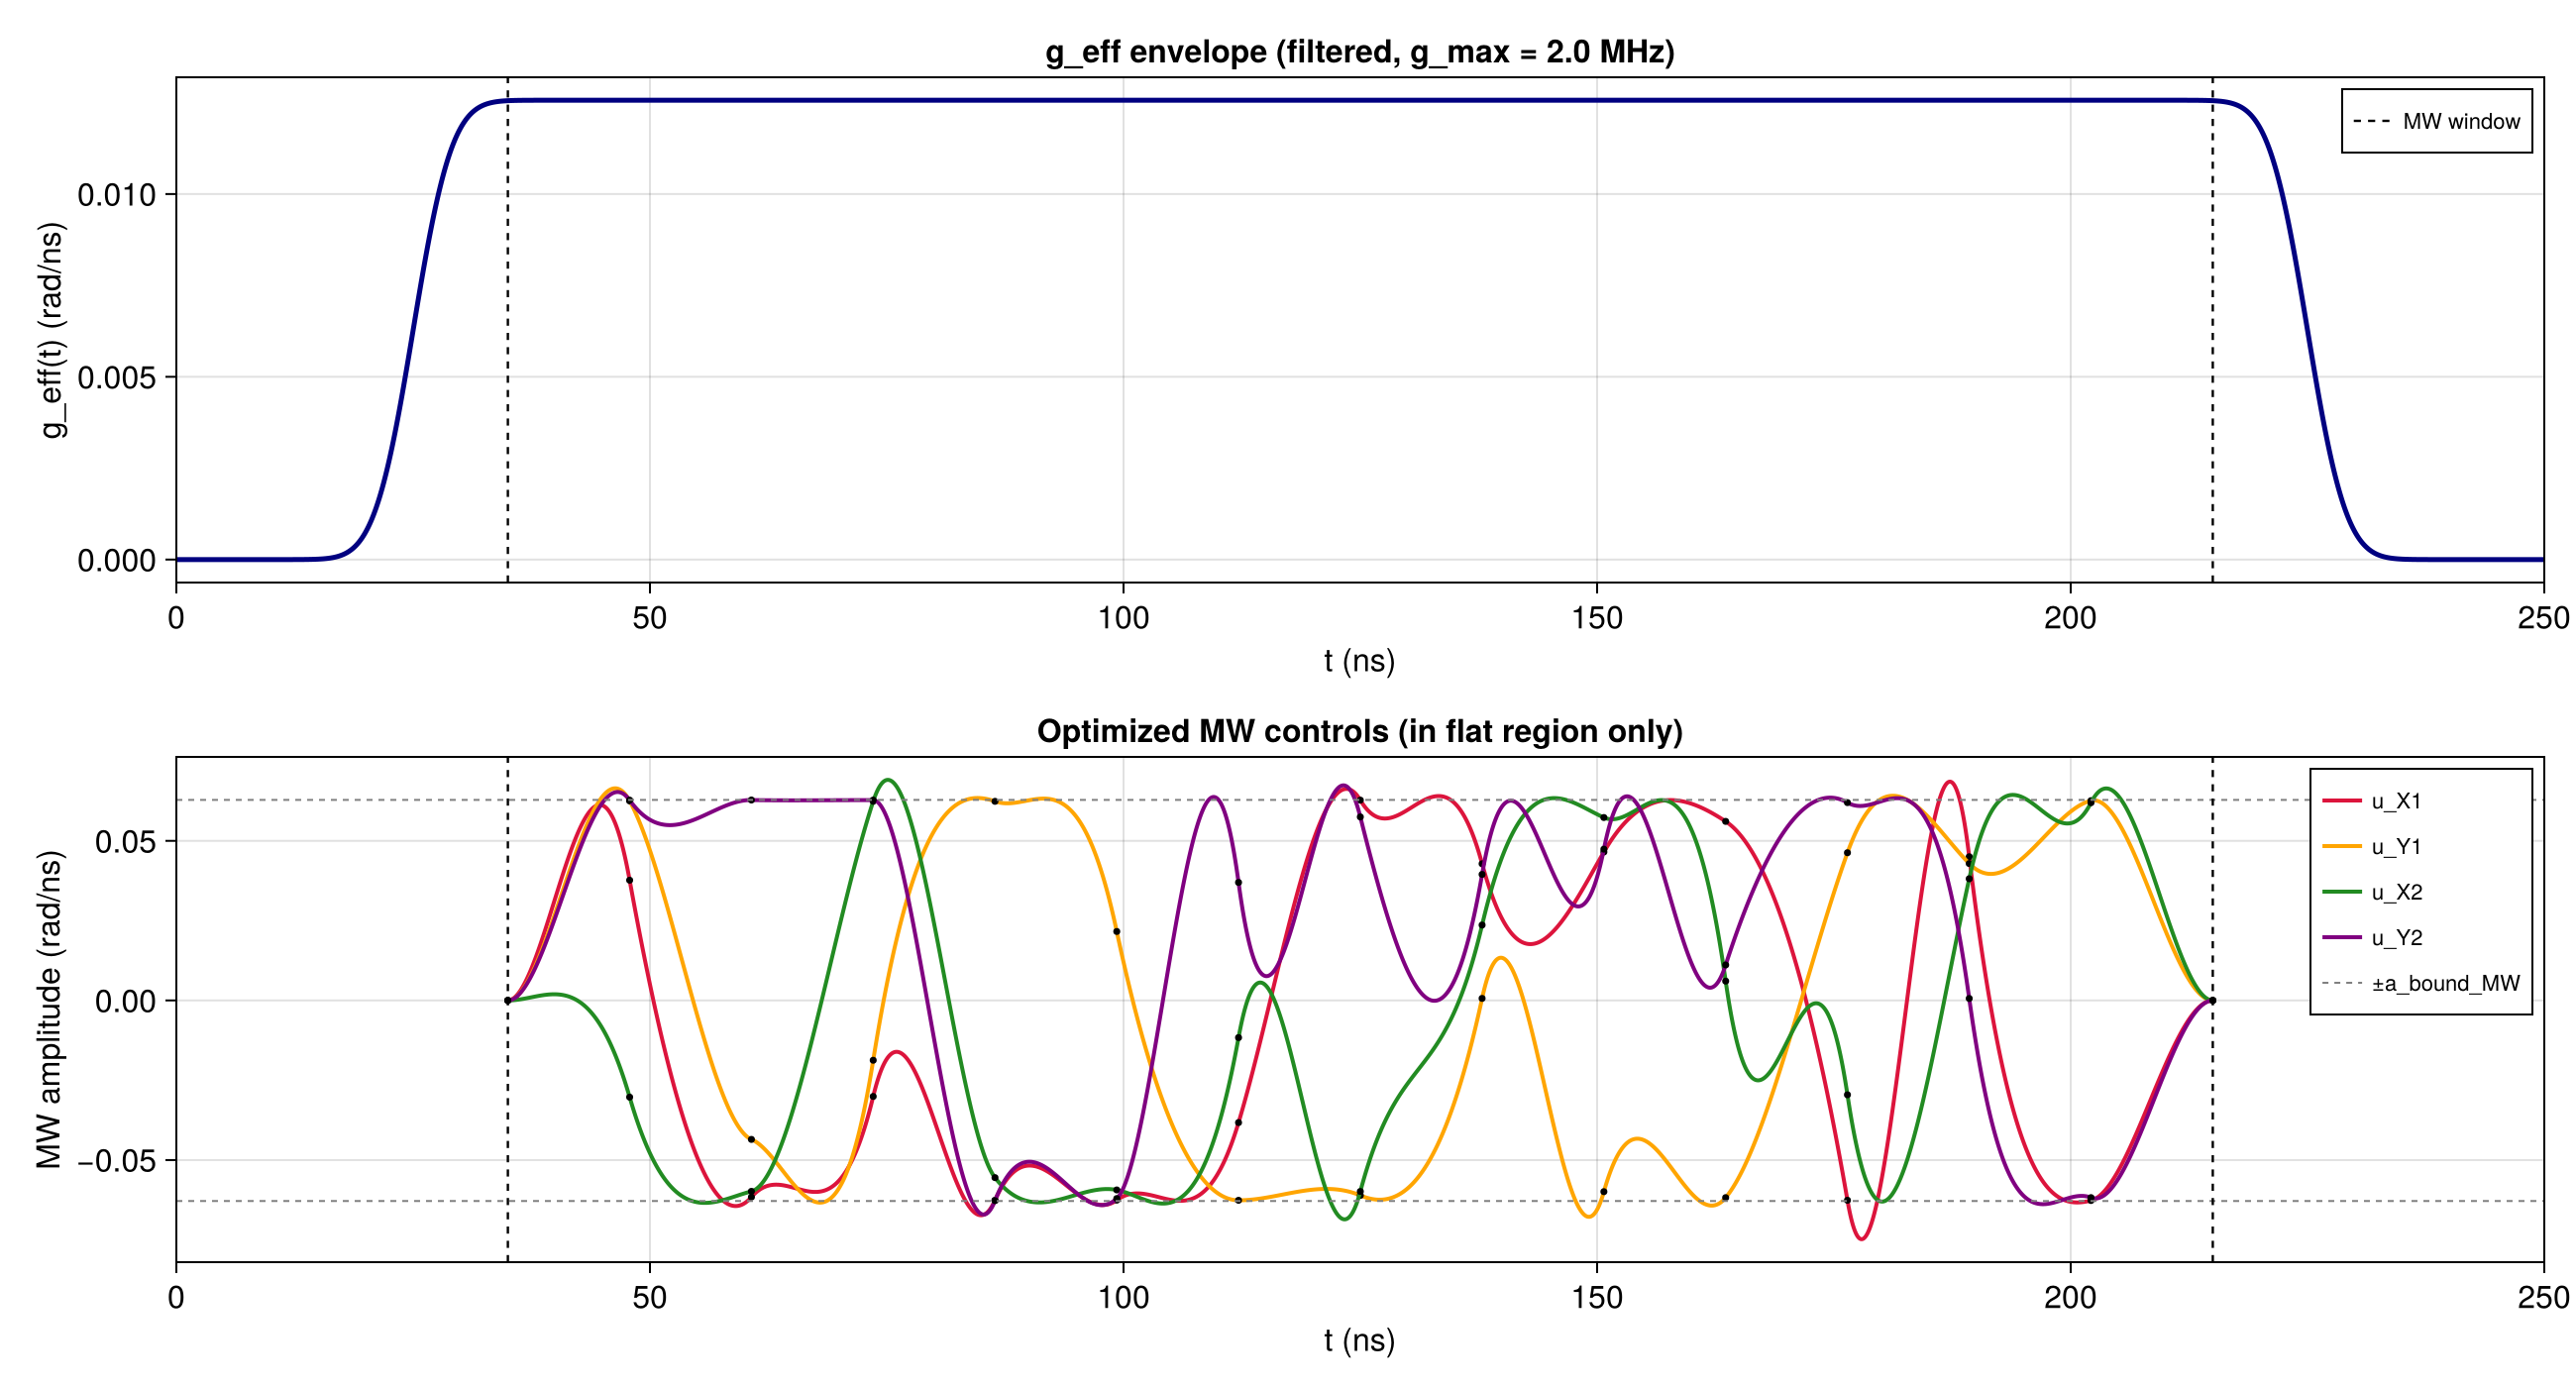

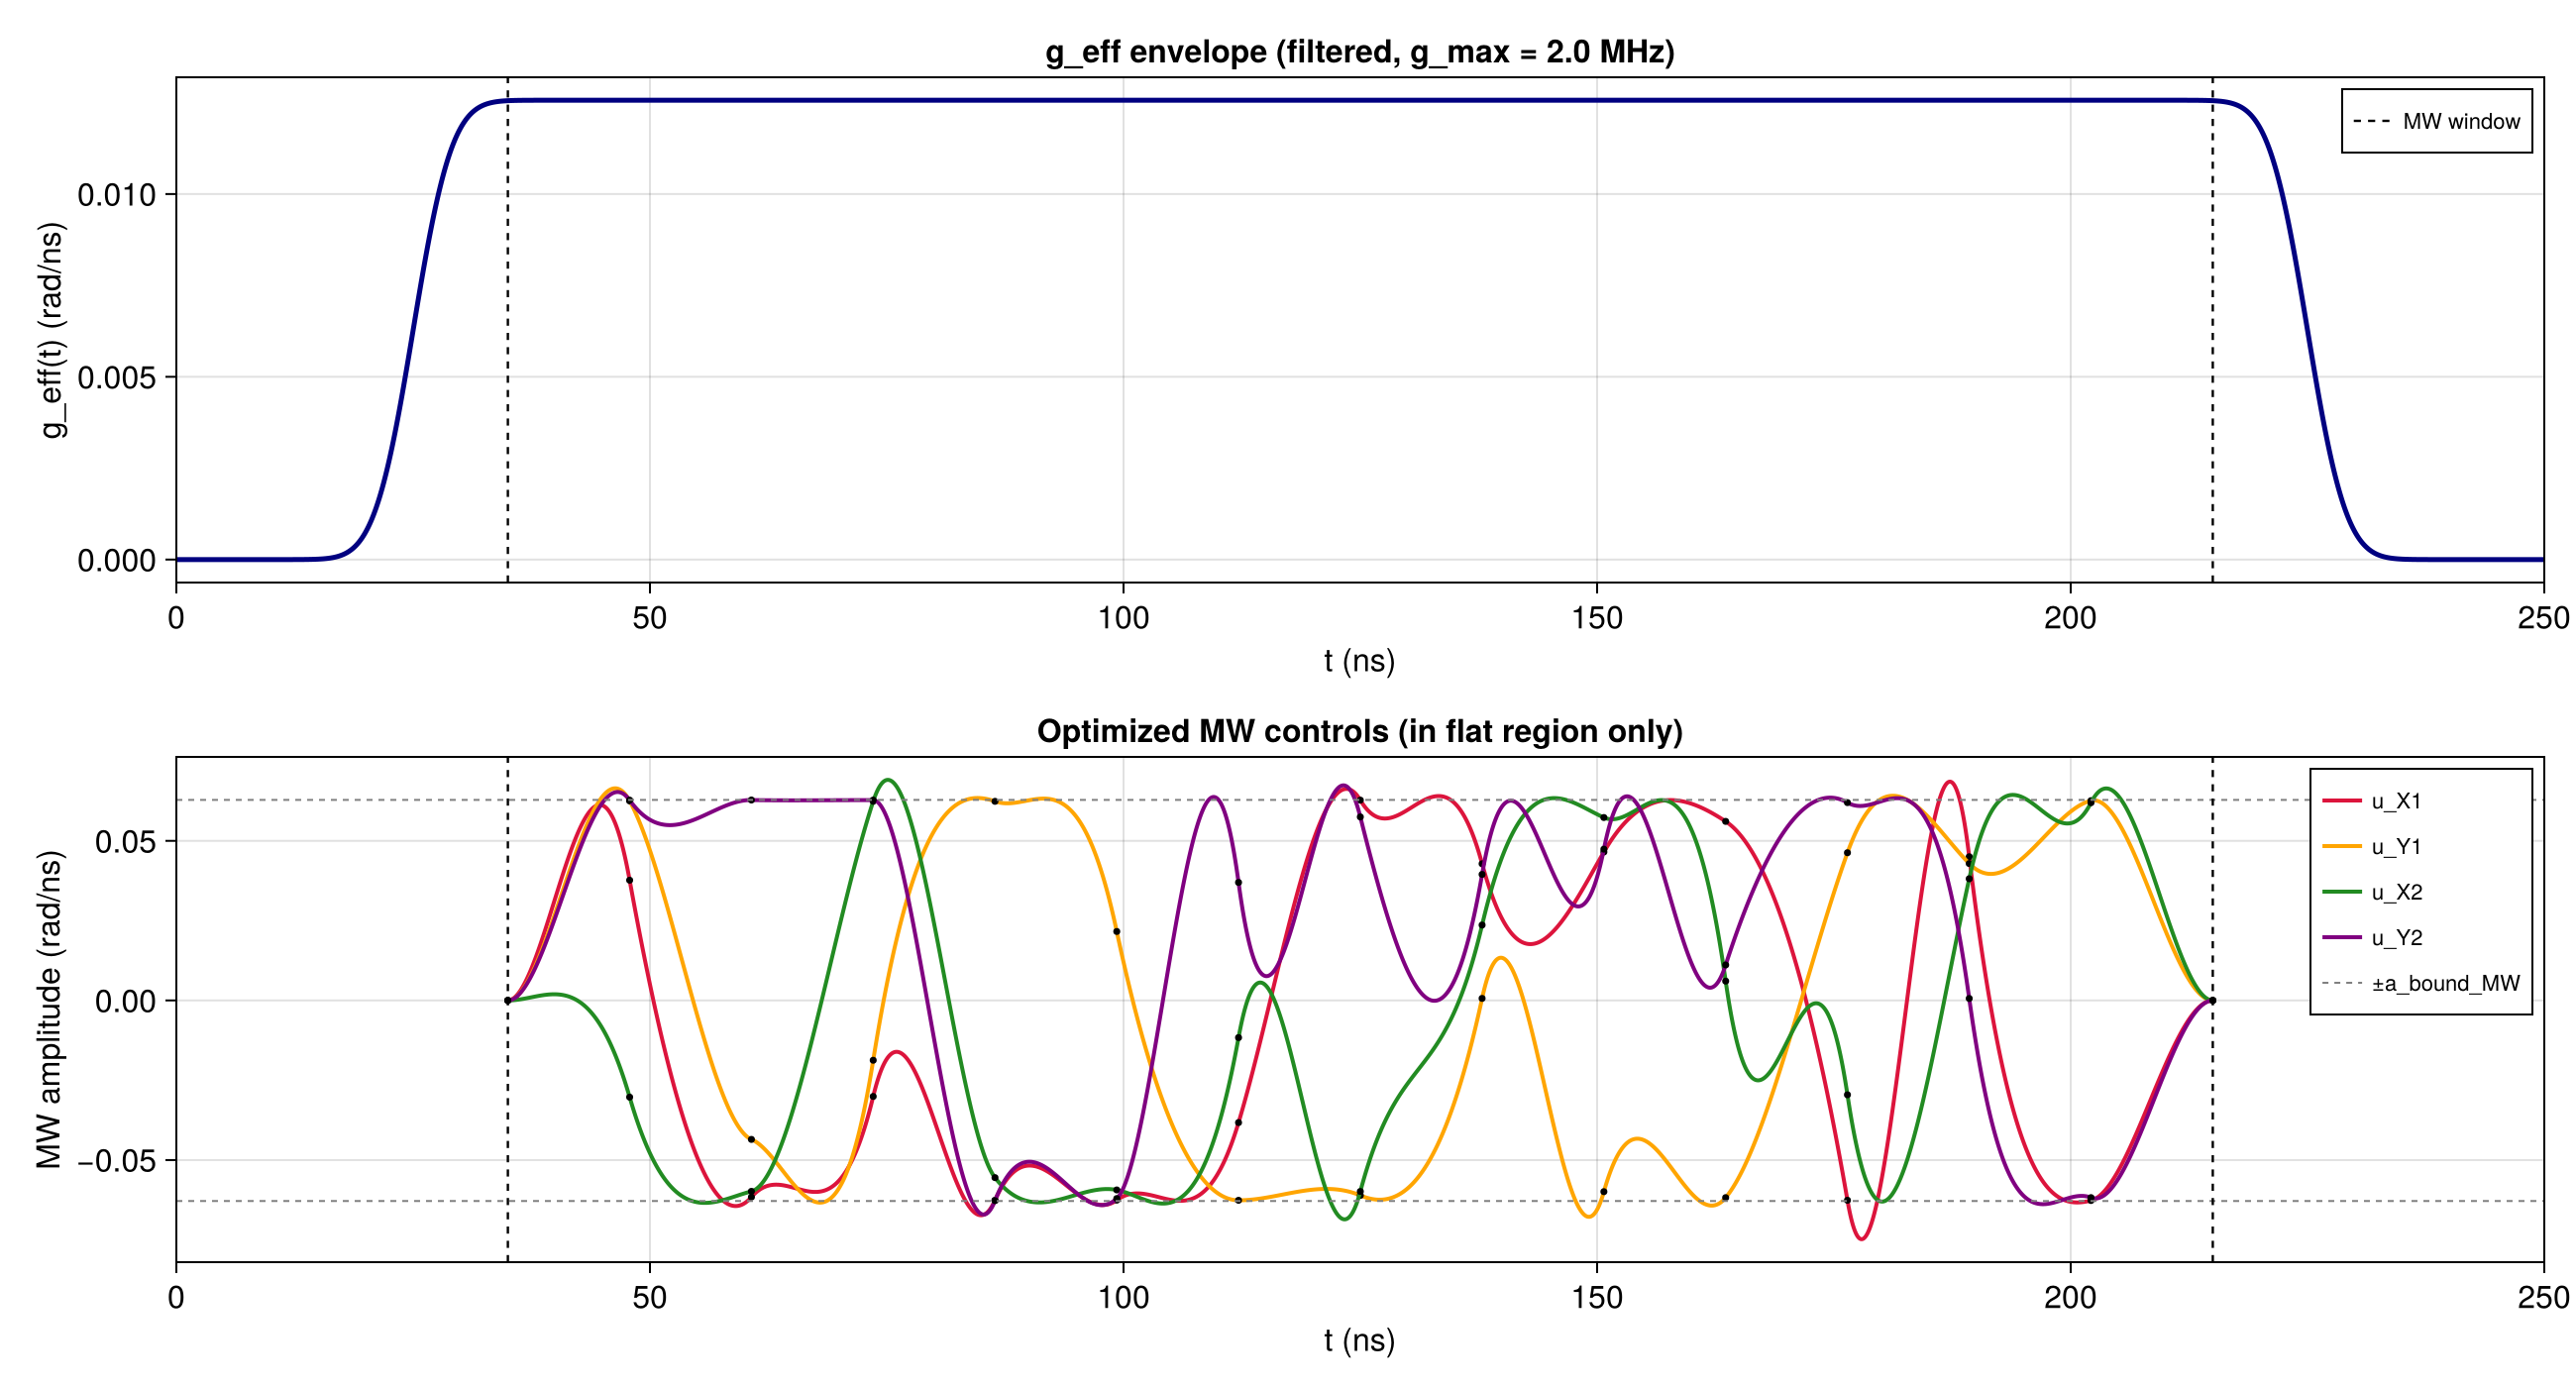

In [15]:
function _spline_fine(traj_local; N = 2000)
    ts_knots_loc = vec(traj_local[:t])
    us_knots_loc = traj_local[:u]
    du_knots_loc = traj_local[:du]
    pulse_loc    = CubicSplinePulse(us_knots_loc, du_knots_loc, ts_knots_loc)
    ts_fine_loc  = collect(LinRange(ts_knots_loc[1], ts_knots_loc[end], N))
    us_fine_loc  = sample(pulse_loc, ts_fine_loc)
    return ts_knots_loc, us_knots_loc, ts_fine_loc, us_fine_loc
end

ts_mw_knots, us_mw_knots, ts_mw_fine, us_mw_fine = _spline_fine(traj_robust)

# Actual MW window length from the optimized trajectory
T_MW_NS         = ts_mw_knots[end]
t_offset        = T_RISE + T_EDGE_MARK
mw_start_abs    = t_offset
mw_end_abs      = t_offset + T_MW_NS
ts_mw_fine_abs  = ts_mw_fine  .+ t_offset
ts_mw_knots_abs = ts_mw_knots .+ t_offset

fig3 = Figure(size = (1300, 700), fontsize = 16)

ax_g = Axis(fig3[1, 1]; xlabel = "t (ns)", ylabel = "g_eff(t) (rad/ns)",
    title = @sprintf("g_eff envelope (filtered, g_max = %.1f MHz)", g_max_MHz))
lines!(ax_g, ts, g_phys; color = :navy, linewidth = 2.5)
vlines!(ax_g, [mw_start_abs, mw_end_abs];
    color = :black, linestyle = :dash, linewidth = 1.2, label = "MW window")
axislegend(ax_g; position = :rt, labelsize = 11)

ax_mw = Axis(fig3[2, 1]; xlabel = "t (ns)", ylabel = "MW amplitude (rad/ns)",
    title = "Optimized MW controls (in flat region only)")
labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]
colors_ctrl = [:crimson, :orange, :forestgreen, :purple]
for (i, (lbl, col)) in enumerate(zip(labels, colors_ctrl))
    lines!(ax_mw, ts_mw_fine_abs, vec(us_mw_fine[i, :]);
        color = col, linewidth = 2.0, label = lbl)
    scatter!(ax_mw, ts_mw_knots_abs, vec(us_mw_knots[i, :]);
        color = :black, markersize = 5)
end
hlines!(ax_mw, [a_bound_MW, -a_bound_MW]; linestyle = :dash, color = :gray,
    linewidth = 1.0, label = "±a_bound_MW")
vlines!(ax_mw, [mw_start_abs, mw_end_abs];
    color = :black, linestyle = :dash, linewidth = 1.2)
axislegend(ax_mw; position = :rt, labelsize = 11)

linkxaxes!(ax_g, ax_mw)
xlims!(ax_g, 0, T_TOTAL_NS)

save(joinpath(@__DIR__, "full_pulse_$(RUN_TAG).png"), fig3; px_per_unit = 4)
display(fig3)
fig3


## 2-lvl ε-sweep: F vs ε under ZI, IZ, ZZ error channels

Verify robustness in 4-dim. For each error operator `V ∈ {ZI, IZ, ZZ}`, propagate the full gate with Hamiltonian `H + ε·V` and report F vs ε. Curves shown both raw and after virtual-Z+ZZ correction.

Default flat-top width  = 62.4886 ns   (target area π/4 = 0.785398)
Default total area      = 0.785446 rad
ZI @ ε=0:   default+vZ = 1.000000    robust(raw) = 0.999855
IZ @ ε=0:   default+vZ = 1.000000    robust(raw) = 0.999855
ZZ @ ε=0:   default+vZ = 1.000000    robust(raw) = 0.999855


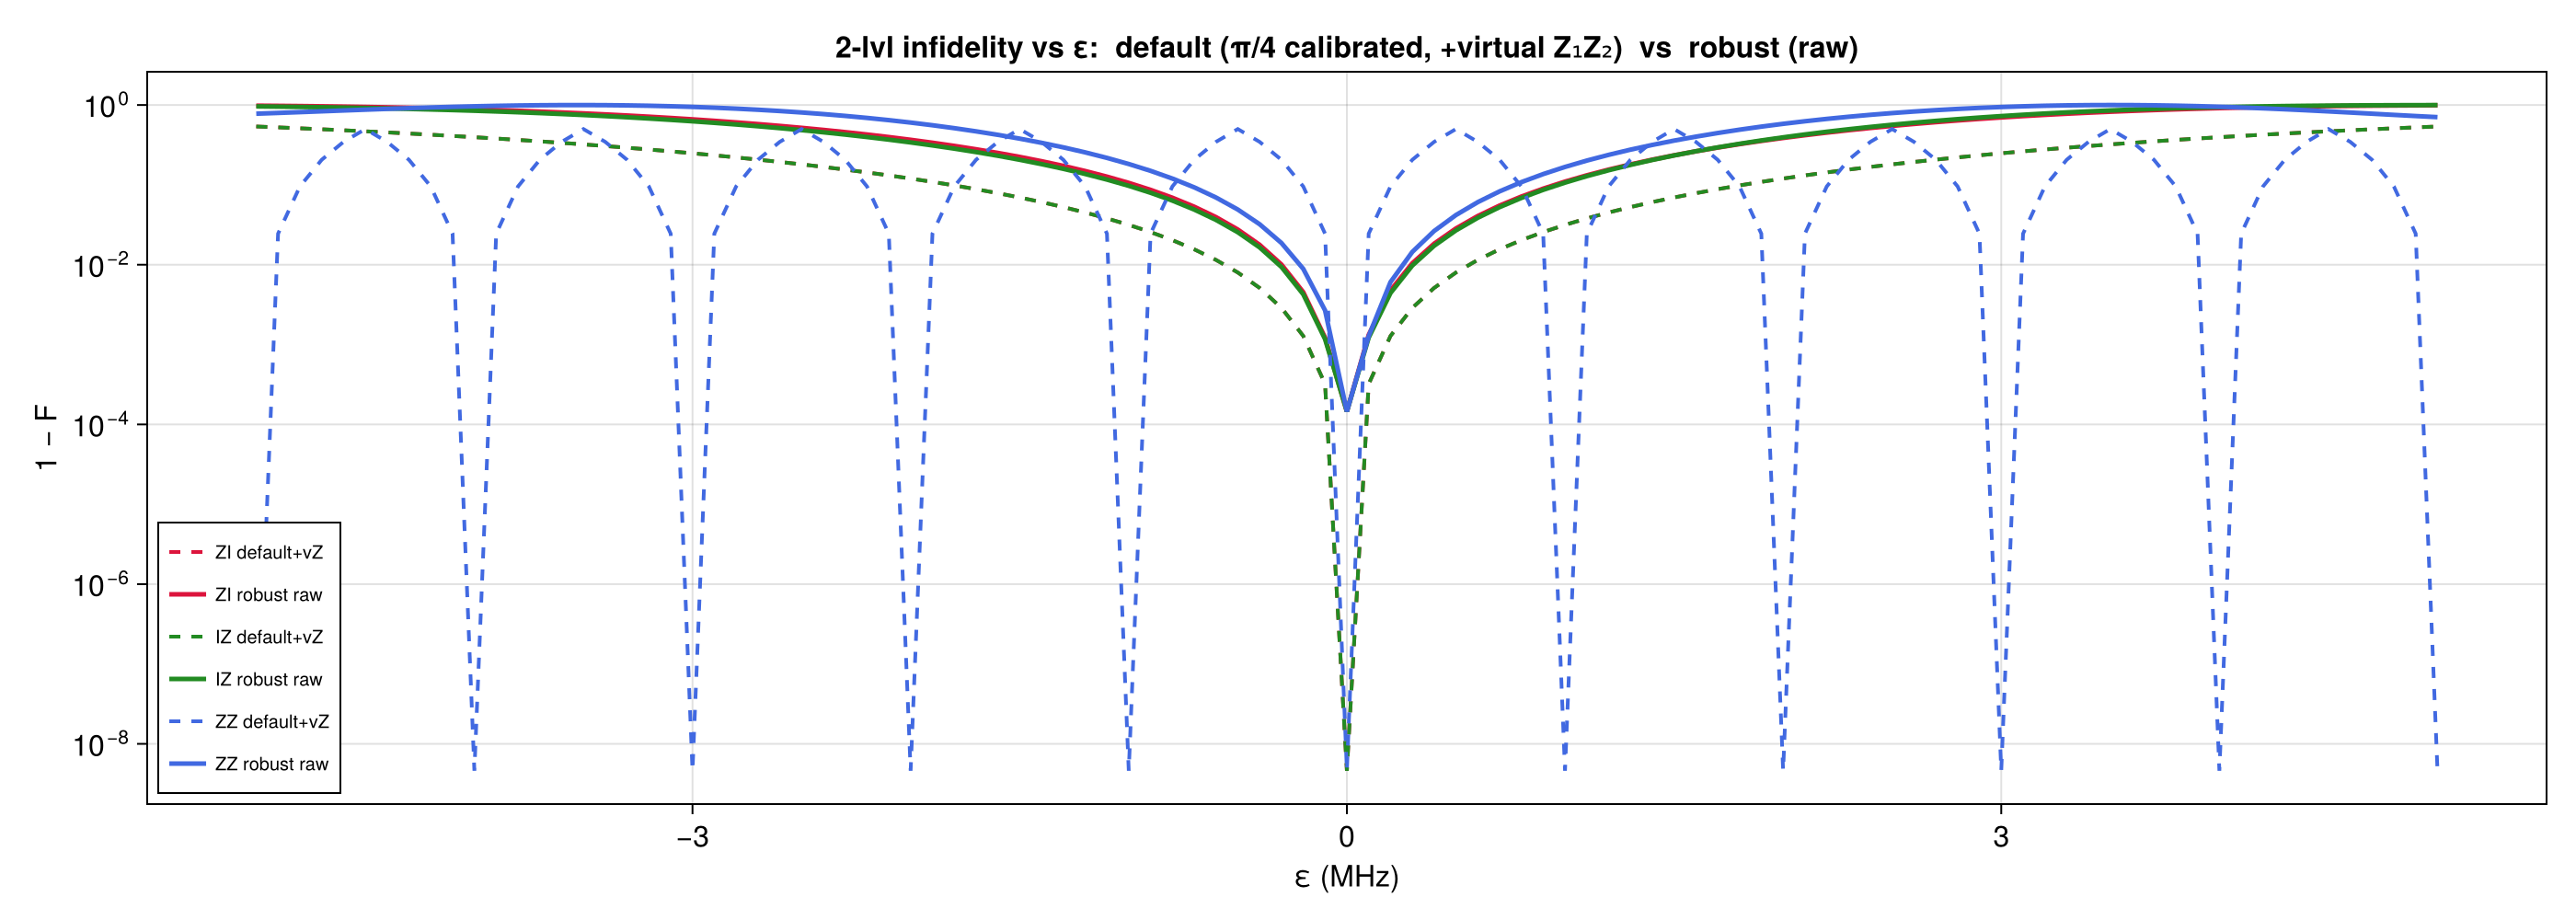

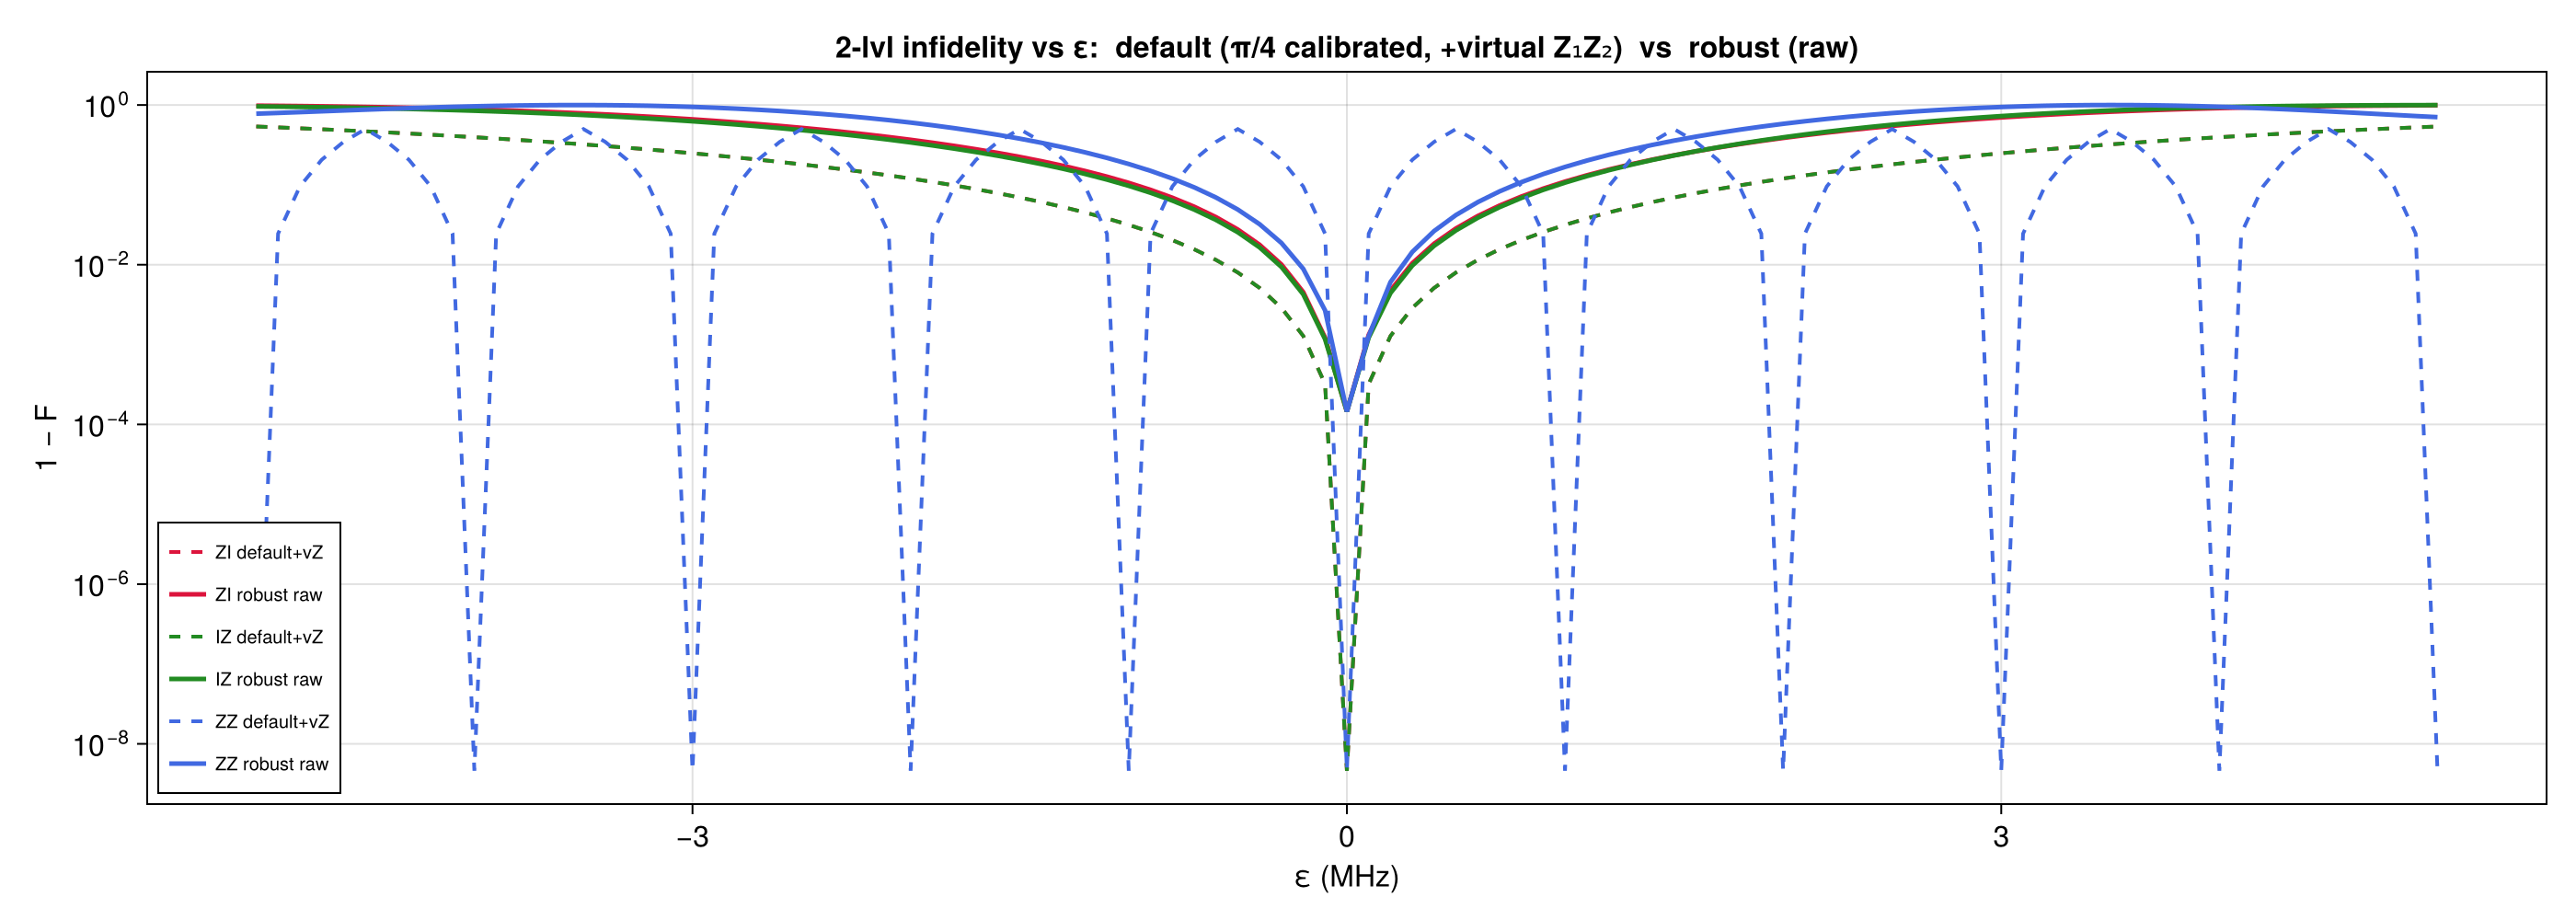

In [16]:
# Per-cell vars (no const so the cell can be re-run safely)
T_MW_NS     = Float64(traj_robust[:t][end])
MW_END_ABS  = T_RISE + T_EDGE_MARK + T_MW_NS
N_EDGE_GRID = 800

# === Robust full-gate propagation (drift + MW + ε) ===
function propagate_full_gate_2lvl(ε_val::Real, ε_op::AbstractMatrix; N_fine = 4000)
    ts_pre = collect(LinRange(0.0, T_RISE + T_EDGE_MARK, N_EDGE_GRID))
    g_pre  = [g_after_AWG[argmin(abs.(ts .- t))] * g_max_rad_per_ns for t in ts_pre]
    U_pre  = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_pre) - 1)
        dt_k  = ts_pre[k+1] - ts_pre[k]
        g_mid = 0.5 * (g_pre[k] + g_pre[k+1])
        H     = g_mid * (XX + YY) + ε_val * ε_op
        U_pre = exp(-im * dt_k * H) * U_pre
    end

    ts_flat_grid = collect(LinRange(0.0, T_MW_NS, N_fine))
    pulse_local  = CubicSplinePulse(traj_robust[:u], traj_robust[:du], vec(traj_robust[:t]))
    us_flat      = sample(pulse_local, ts_flat_grid)
    U_flat       = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_flat_grid) - 1)
        dt_k  = ts_flat_grid[k+1] - ts_flat_grid[k]
        u_mid = 0.5 .* (us_flat[:, k] .+ us_flat[:, k+1])
        H = g_flat * (XX + YY) + u_mid[1] * XI + u_mid[2] * YI + u_mid[3] * IX + u_mid[4] * IY + ε_val * ε_op
        U_flat = exp(-im * dt_k * H) * U_flat
    end

    ts_post = collect(LinRange(MW_END_ABS, T_TOTAL_NS, N_EDGE_GRID))
    g_post  = [g_after_AWG[argmin(abs.(ts .- t))] * g_max_rad_per_ns for t in ts_post]
    U_post  = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_post) - 1)
        dt_k  = ts_post[k+1] - ts_post[k]
        g_mid = 0.5 * (g_post[k] + g_post[k+1])
        H     = g_mid * (XX + YY) + ε_val * ε_op
        U_post = exp(-im * dt_k * H) * U_post
    end

    return U_post * U_flat * U_pre
end

# === Default: filtered Gaussian-square calibrated so total area = π/4 (one iSWAP) ===
function build_default_env(W_flat::Float64)
    ts_loc = collect(LinRange(0.0, T_TOTAL_NS, N_FINE))
    dt_loc = ts_loc[2] - ts_loc[1]
    t_c    = T_TOTAL_NS / 2
    g_sq   = [(t_c - W_flat/2 ≤ t ≤ t_c + W_flat/2) ? g_max : 0.0 for t in ts_loc]
    g_a    = gaussian_lowpass(g_sq, dt_loc, σ_f_anh_MHz)
    g_b    = gaussian_lowpass(g_a,  dt_loc, σ_f_AWG_MHz)
    return ts_loc, g_b
end

function default_area(W_flat::Float64)
    ts_loc, g_b = build_default_env(W_flat)
    dt_loc = ts_loc[2] - ts_loc[1]
    return sum(g_b) * dt_loc * g_max_rad_per_ns
end

# Bisect W_flat so the calibrated area = π/4
lo, hi = 0.0, T_TOTAL_NS * 0.9
for _ in 1:80
    mid = (lo + hi) / 2
    default_area(mid) < π/4 ? (lo = mid) : (hi = mid)
end
W_DEF = (lo + hi) / 2
ts_def, g_def_norm = build_default_env(W_DEF)
g_def_phys = g_def_norm .* g_max_rad_per_ns

@printf("Default flat-top width  = %.4f ns   (target area π/4 = %.6f)\n", W_DEF, π/4)
@printf("Default total area      = %.6f rad\n", sum(g_def_phys) * (ts_def[2] - ts_def[1]))

function propagate_default_2lvl(ε_val::Real, ε_op::AbstractMatrix)
    U = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_def) - 1)
        dt_k  = ts_def[k+1] - ts_def[k]
        g_mid = 0.5 * (g_def_phys[k] + g_def_phys[k+1])
        H     = g_mid * (XX + YY) + ε_val * ε_op
        U     = exp(-im * dt_k * H) * U
    end
    return U
end

# === ε sweep ===
εs_MHz_2q = collect(LinRange(-5.0, 5.0, 101))
εs_rad    = 2π .* εs_MHz_2q .* 1e-3
err_channels = [(:ZI, ZI), (:IZ, IZ), (:ZZ, ZZ)]

F_def_vc_vs_eps  = Dict{Symbol, Vector{Float64}}()
F_rob_raw_vs_eps = Dict{Symbol, Vector{Float64}}()

for (name, op) in err_channels
    F_def = Float64[]; F_rob = Float64[]
    for ε in εs_rad
        U_def = propagate_default_2lvl(ε, op)
        U_rob = propagate_full_gate_2lvl(ε, op)
        push!(F_def, virtual_corrected_fidelity_Zonly(U_def)[1])
        push!(F_rob, abs2(tr(U_iSWAP' * U_rob)) / 16)
    end
    F_def_vc_vs_eps[name]  = F_def
    F_rob_raw_vs_eps[name] = F_rob
    i0 = argmin(abs.(εs_MHz_2q))
    @printf("%s @ ε=0:   default+vZ = %.6f    robust(raw) = %.6f\n",
        string(name), F_def[i0], F_rob[i0])
end

fig4 = Figure(size = (1400, 500), fontsize = 16)
ax_F = Axis(fig4[1, 1]; xlabel = "ε (MHz)", ylabel = "1 − F",
    yscale = log10,
    title = "2-lvl infidelity vs ε:  default (π/4 calibrated, +virtual Z₁Z₂)  vs  robust (raw)")
channel_colors = Dict(:ZI => :crimson, :IZ => :forestgreen, :ZZ => :royalblue)
for (name, _) in err_channels
    c = channel_colors[name]
    lines!(ax_F, εs_MHz_2q, max.(1 .- F_def_vc_vs_eps[name], 1e-12);
        color = c, linewidth = 2.0, linestyle = :dash, label = "$(string(name)) default+vZ")
    lines!(ax_F, εs_MHz_2q, max.(1 .- F_rob_raw_vs_eps[name], 1e-12);
        color = c, linewidth = 2.5, label = "$(string(name)) robust raw")
end
axislegend(ax_F; position = :lb, labelsize = 10)
save(joinpath(@__DIR__, "eps_sweep_2lvl_default_vs_robust_$(RUN_TAG).png"), fig4; px_per_unit = 4)
display(fig4)
fig4

## 3-lvl honest verification (9-dim Hilbert space)

Promote each qubit to 3 levels, propagate the full gate (edges + MW), report `F_3` (qubit-subspace fidelity), `L_3` (leakage out of qubit subspace), and ε-sweep against ZI₍3₎, IZ₍3₎ in the 9-dim space.

In [17]:
# 3-lvl-per-qubit operators (9-dim) — no const so cell can be re-run
I_9     = Matrix{ComplexF64}(I, 9, 9)
I_3lvl  = Matrix{ComplexF64}(I, 3, 3)
a_3     = ComplexF64[0 1 0; 0 0 sqrt(2); 0 0 0]
a1_9    = kron(a_3, I_3lvl)
a2_9    = kron(I_3lvl, a_3)
n1_9    = a1_9' * a1_9
n2_9    = a2_9' * a2_9
XI_9    = a1_9 + a1_9'
YI_9    = im * (a1_9' - a1_9)
IX_9    = a2_9 + a2_9'
IY_9    = im * (a2_9' - a2_9)
exch_9  = XI_9 * IX_9 + YI_9 * IY_9               # = 2·(a₁†a₂ + a₁a₂†), matches g·(XX+YY)

η_rad   = -2π * η_MHz * 1e-3
H_anh_9 = (η_rad / 2) * (n1_9 * (n1_9 - I_9) + n2_9 * (n2_9 - I_9))

QSUB = [1, 2, 4, 5]

function propagate_full_gate_3lvl(ε_val::Real, ε_op_9::AbstractMatrix; N_fine = 4000)
    # Pre-flat region (drift+anharmonicity+ε)
    ts_pre = collect(LinRange(0.0, T_RISE + T_EDGE_MARK, N_EDGE_GRID))
    g_pre  = [g_after_AWG[argmin(abs.(ts .- t))] * g_max_rad_per_ns for t in ts_pre]
    U_pre  = Matrix{ComplexF64}(I, 9, 9)
    @inbounds for k in 1:(length(ts_pre) - 1)
        dt_k  = ts_pre[k+1] - ts_pre[k]
        g_mid = 0.5 * (g_pre[k] + g_pre[k+1])
        H = H_anh_9 + g_mid * exch_9 + ε_val * ε_op_9
        U_pre = exp(-im * dt_k * H) * U_pre
    end

    # Flat region with MW
    ts_flat_grid = collect(LinRange(0.0, T_MW_NS, N_fine))
    pulse_local  = CubicSplinePulse(traj_robust[:u], traj_robust[:du], vec(traj_robust[:t]))
    us_flat      = sample(pulse_local, ts_flat_grid)
    U_flat = Matrix{ComplexF64}(I, 9, 9)
    @inbounds for k in 1:(length(ts_flat_grid) - 1)
        dt_k  = ts_flat_grid[k+1] - ts_flat_grid[k]
        u_mid = 0.5 .* (us_flat[:, k] .+ us_flat[:, k+1])
        H = H_anh_9 + g_flat * exch_9 + u_mid[1] * XI_9 + u_mid[2] * YI_9 + u_mid[3] * IX_9 + u_mid[4] * IY_9 + ε_val * ε_op_9
        U_flat = exp(-im * dt_k * H) * U_flat
    end

    # Post-flat region
    ts_post = collect(LinRange(MW_END_ABS, T_TOTAL_NS, N_EDGE_GRID))
    g_post  = [g_after_AWG[argmin(abs.(ts .- t))] * g_max_rad_per_ns for t in ts_post]
    U_post  = Matrix{ComplexF64}(I, 9, 9)
    @inbounds for k in 1:(length(ts_post) - 1)
        dt_k  = ts_post[k+1] - ts_post[k]
        g_mid = 0.5 * (g_post[k] + g_post[k+1])
        H = H_anh_9 + g_mid * exch_9 + ε_val * ε_op_9
        U_post = exp(-im * dt_k * H) * U_post
    end

    return U_post * U_flat * U_pre
end

# Optimized at ε = 0
U_3lvl_0  = propagate_full_gate_3lvl(0.0, zeros(ComplexF64, 9, 9))
U_sub_0   = U_3lvl_0[QSUB, QSUB]
F_3_raw_0 = abs2(tr(U_iSWAP' * U_sub_0)) / 16
F_3_vc_0  = virtual_corrected_fidelity_Zonly(U_sub_0)[1]
L_3_0     = 1 - real(tr(U_sub_0' * U_sub_0)) / 4

@printf("\n=== 3-lvl at ε = 0 (full gate, optimized) ===\n")
@printf("F_3 raw                = %.8f   (1−F = %.3e)\n", F_3_raw_0, 1 - F_3_raw_0)
@printf("F_3 after virtual Z₁Z₂ = %.8f   (1−F = %.3e)\n", F_3_vc_0,  1 - F_3_vc_0)
@printf("L_3                    = %.3e\n", L_3_0)

# Default 3-lvl: calibrated Gaussian-square envelope, no MW
function propagate_default_3lvl()
    U = Matrix{ComplexF64}(I, 9, 9)
    @inbounds for k in 1:(length(ts_def) - 1)
        dt_k  = ts_def[k+1] - ts_def[k]
        g_mid = 0.5 * (g_def_phys[k] + g_def_phys[k+1])
        H = H_anh_9 + g_mid * exch_9
        U = exp(-im * dt_k * H) * U
    end
    return U
end

U_def_3lvl  = propagate_default_3lvl()
U_def_sub   = U_def_3lvl[QSUB, QSUB]
F_3_def_raw = abs2(tr(U_iSWAP' * U_def_sub)) / 16
F_3_def_vc  = virtual_corrected_fidelity_Zonly(U_def_sub)[1]
L_3_def     = 1 - real(tr(U_def_sub' * U_def_sub)) / 4

@printf("\n=== 3-lvl at ε = 0 (default calibrated, NO MW) ===\n")
@printf("F_3 raw                = %.8f   (1−F = %.3e)\n", F_3_def_raw, 1 - F_3_def_raw)
@printf("F_3 after virtual Z₁Z₂ = %.8f   (1−F = %.3e)\n", F_3_def_vc,  1 - F_3_def_vc)
@printf("L_3                    = %.3e\n", L_3_def)


=== 3-lvl at ε = 0 (full gate, optimized) ===
F_3 raw                = 0.93906489   (1−F = 6.094e-02)
F_3 after virtual Z₁Z₂ = 0.93996536   (1−F = 6.003e-02)
L_3                    = 4.548e-03

=== 3-lvl at ε = 0 (default calibrated, NO MW) ===
F_3 raw                = 0.99636637   (1−F = 3.634e-03)
F_3 after virtual Z₁Z₂ = 0.99876402   (1−F = 1.236e-03)
L_3                    = 1.140e-08


3-lvl ZI @ ε=0:  robust F=0.939065 L=4.548e-03   default F=0.996366 L=1.140e-08
3-lvl IZ @ ε=0:  robust F=0.939065 L=4.548e-03   default F=0.996366 L=1.140e-08
3-lvl ZZ @ ε=0:  robust F=0.939065 L=4.548e-03   default F=0.996366 L=1.140e-08


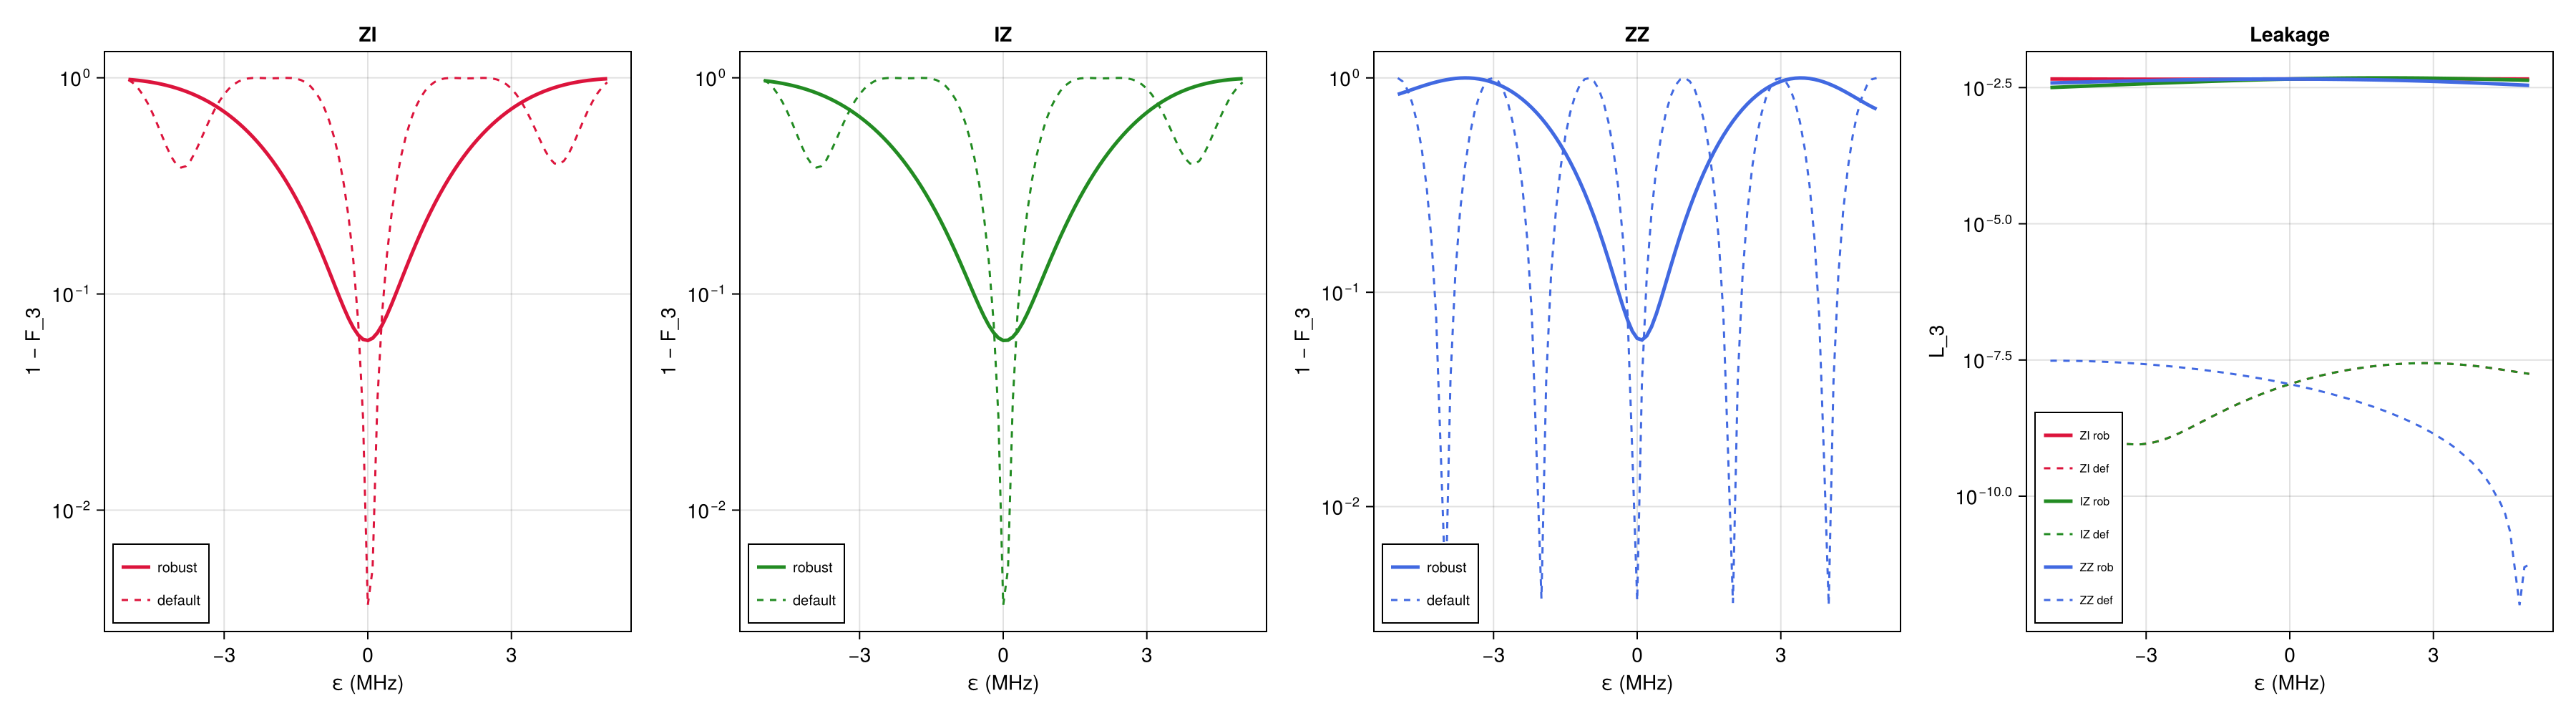

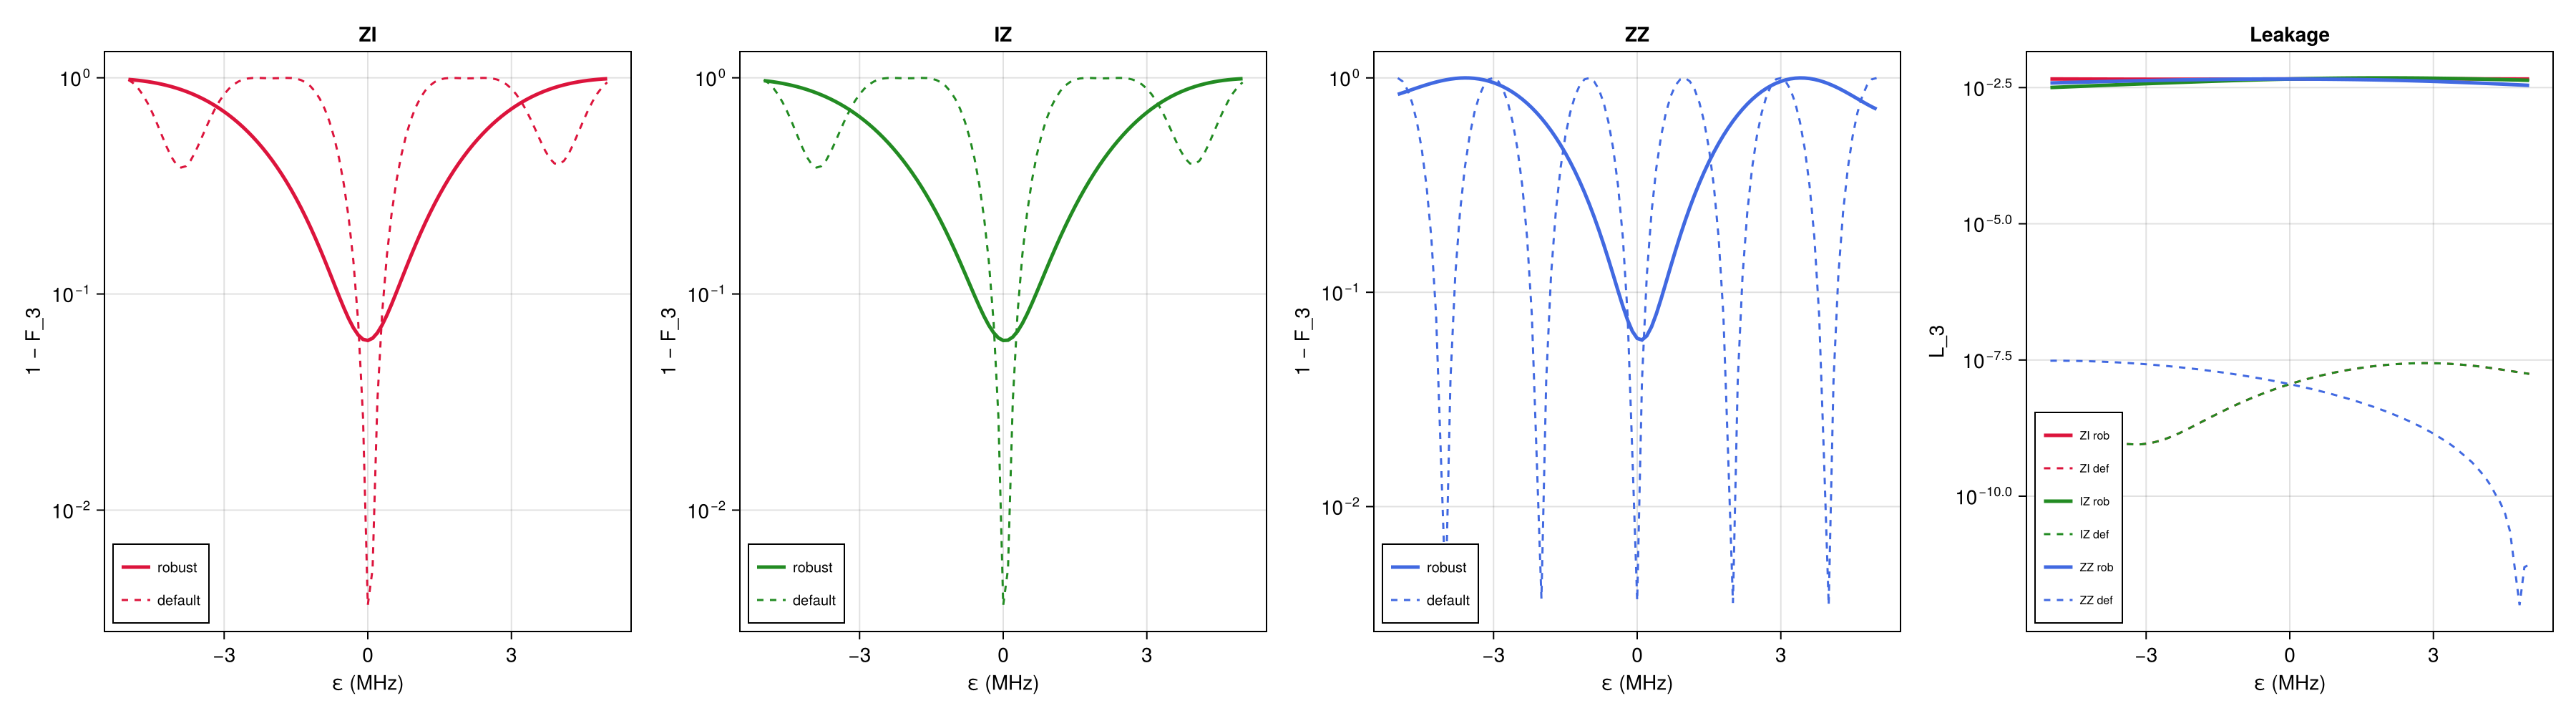

In [22]:
# 3-lvl ε-sweep — robust vs default, no virtual Z, no post-processing.
ZI_9 = kron(ComplexF64[1 0 0; 0 -1 0; 0 0 0], I_3lvl)
IZ_9 = kron(I_3lvl, ComplexF64[1 0 0; 0 -1 0; 0 0 0])
ZZ_9 = ZI_9 * IZ_9

err_channels_3lvl = [(:ZI, ZI_9), (:IZ, IZ_9), (:ZZ, ZZ_9)]

# Default 3-lvl with ε (calibrated Gaussian-square, no MW)
function propagate_default_3lvl_with_eps(ε_val::Real, ε_op_9::AbstractMatrix)
    U = Matrix{ComplexF64}(I, 9, 9)
    @inbounds for k in 1:(length(ts_def) - 1)
        dt_k  = ts_def[k+1] - ts_def[k]
        g_mid = 0.5 * (g_def_phys[k] + g_def_phys[k+1])
        H = H_anh_9 + g_mid * exch_9 + ε_val * ε_op_9
        U = exp(-im * dt_k * H) * U
    end
    return U
end

F3_rob_vs_eps = Dict{Symbol, Vector{Float64}}()
L3_rob_vs_eps = Dict{Symbol, Vector{Float64}}()
F3_def_vs_eps = Dict{Symbol, Vector{Float64}}()
L3_def_vs_eps = Dict{Symbol, Vector{Float64}}()

for (name, op) in err_channels_3lvl
    Fr = Float64[]; Lr = Float64[]
    Fd = Float64[]; Ld = Float64[]
    for ε in εs_rad
        U_r = propagate_full_gate_3lvl(ε, op)
        U_d = propagate_default_3lvl_with_eps(ε, op)
        U_rs = U_r[QSUB, QSUB]
        U_ds = U_d[QSUB, QSUB]
        push!(Fr, abs2(tr(U_iSWAP' * U_rs)) / 16)
        push!(Lr, 1 - real(tr(U_rs' * U_rs)) / 4)
        push!(Fd, abs2(tr(U_iSWAP' * U_ds)) / 16)
        push!(Ld, 1 - real(tr(U_ds' * U_ds)) / 4)
    end
    F3_rob_vs_eps[name] = Fr; L3_rob_vs_eps[name] = Lr
    F3_def_vs_eps[name] = Fd; L3_def_vs_eps[name] = Ld
    i0 = argmin(abs.(εs_MHz_2q))
    @printf("3-lvl %s @ ε=0:  robust F=%.6f L=%.3e   default F=%.6f L=%.3e\n",
        string(name), Fr[i0], Lr[i0], Fd[i0], Ld[i0])
end

ch_colors_3lvl = Dict(:ZI => :crimson, :IZ => :forestgreen, :ZZ => :royalblue)

fig5 = Figure(size = (1800, 500), fontsize = 14)
ax_ZI = Axis(fig5[1, 1]; xlabel = "ε (MHz)", ylabel = "1 − F_3", yscale = log10, title = "ZI")
ax_IZ = Axis(fig5[1, 2]; xlabel = "ε (MHz)", ylabel = "1 − F_3", yscale = log10, title = "IZ")
ax_ZZ = Axis(fig5[1, 3]; xlabel = "ε (MHz)", ylabel = "1 − F_3", yscale = log10, title = "ZZ")
ax_L  = Axis(fig5[1, 4]; xlabel = "ε (MHz)", ylabel = "L_3",    yscale = log10, title = "Leakage")

axes_F = Dict(:ZI => ax_ZI, :IZ => ax_IZ, :ZZ => ax_ZZ)

for (name, _) in err_channels_3lvl
    ax = axes_F[name]
    c  = ch_colors_3lvl[name]
    lines!(ax, εs_MHz_2q, max.(1 .- F3_rob_vs_eps[name], 1e-12);
        color = c, linewidth = 2.5, label = "robust")
    lines!(ax, εs_MHz_2q, max.(1 .- F3_def_vs_eps[name], 1e-12);
        color = c, linewidth = 1.5, linestyle = :dash, label = "default")
    axislegend(ax; position = :lb, labelsize = 10)

    lines!(ax_L, εs_MHz_2q, max.(L3_rob_vs_eps[name], 1e-12);
        color = c, linewidth = 2.5, label = "$(string(name)) rob")
    lines!(ax_L, εs_MHz_2q, max.(L3_def_vs_eps[name], 1e-12);
        color = c, linewidth = 1.5, linestyle = :dash, label = "$(string(name)) def")
end
axislegend(ax_L; position = :lb, labelsize = 8)

save(joinpath(@__DIR__, "eps_sweep_3lvl_$(RUN_TAG).png"), fig5; px_per_unit = 4)
display(fig5)
fig5

MW spectrum at ±170 MHz (vs ε_max = 1e-02):
  |Ω̂_1(+η)|² = 3.746e-05    |Ω̂_1(−η)|² = 1.085e-03
  |Ω̂_2(+η)|² = 3.635e-03    |Ω̂_2(−η)|² = 5.038e-04


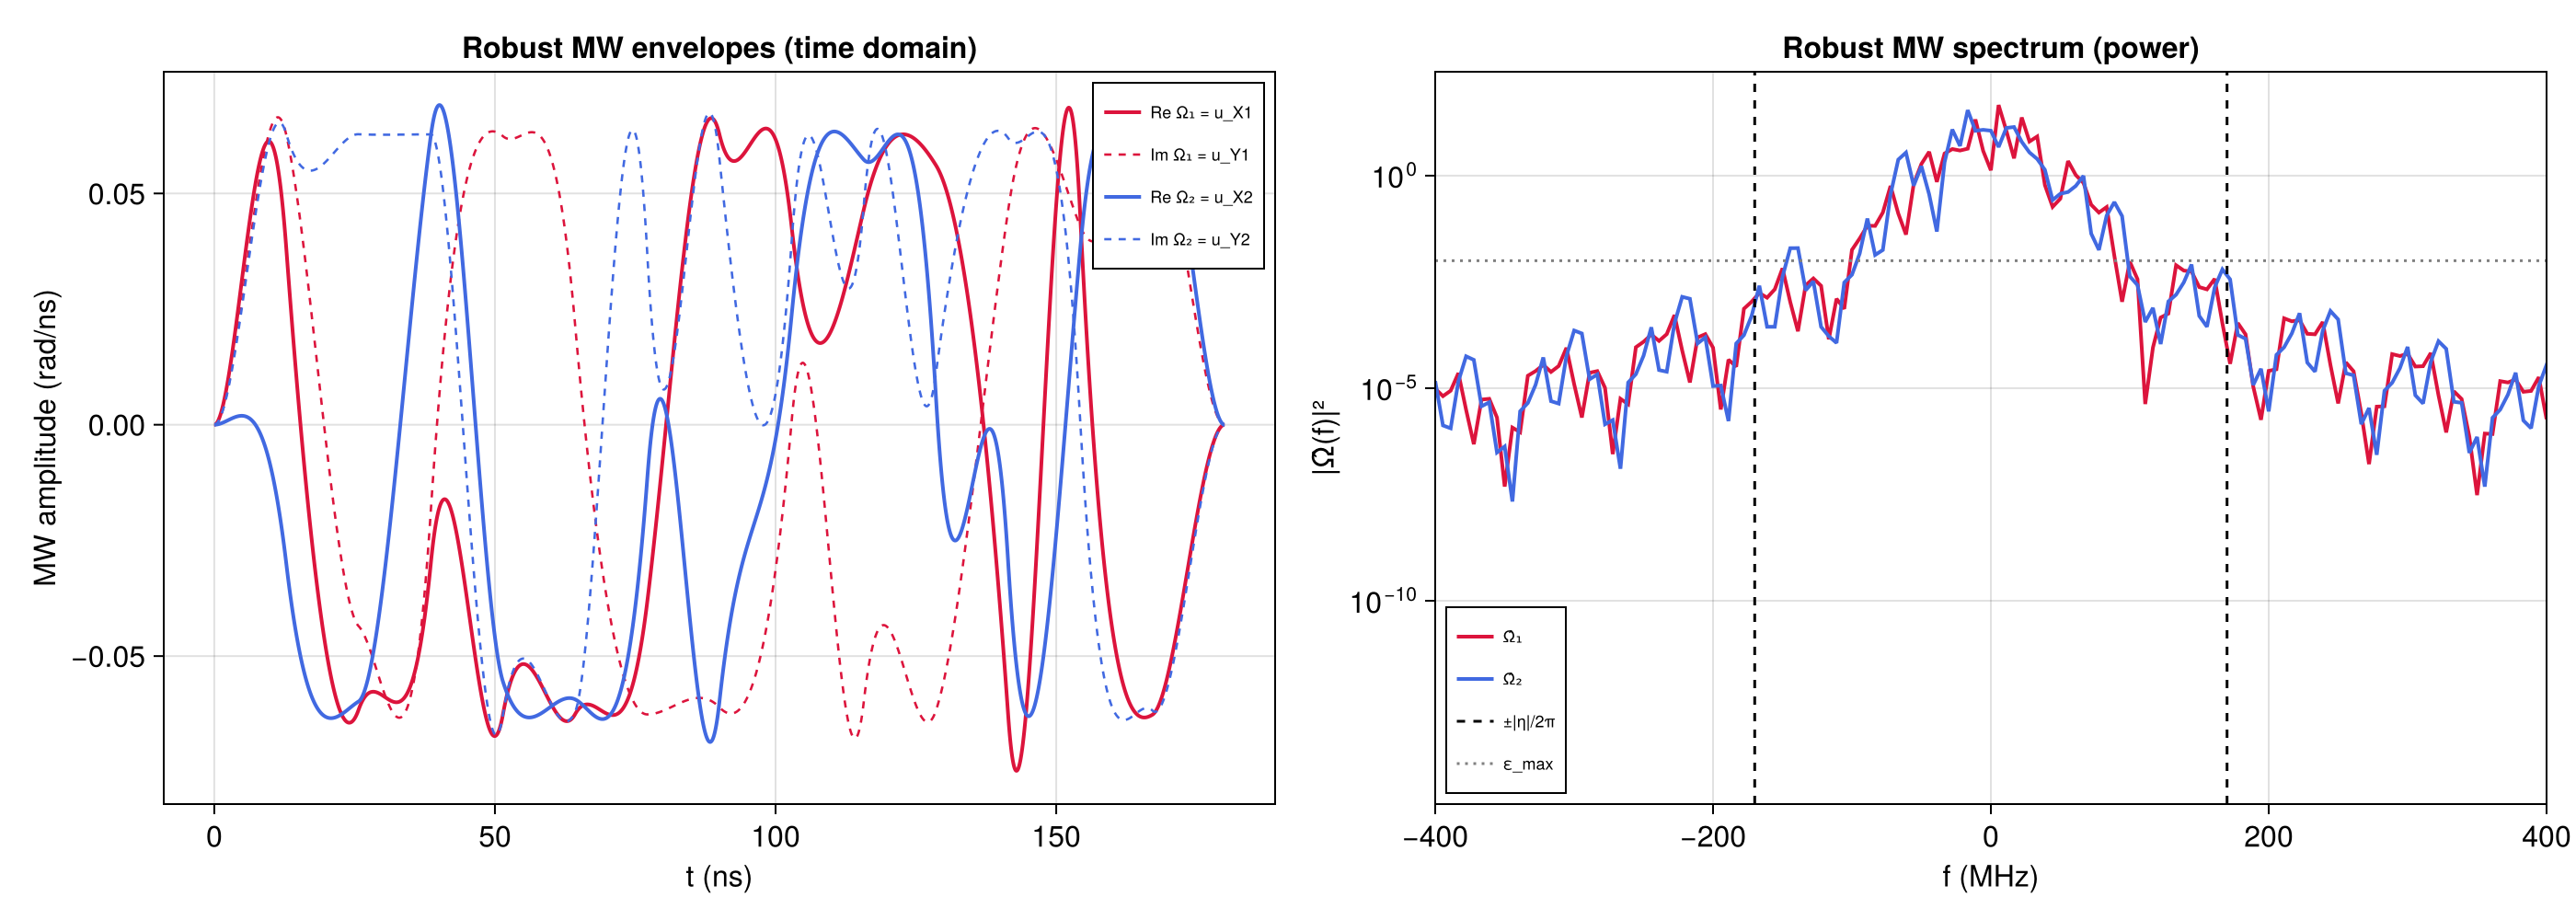

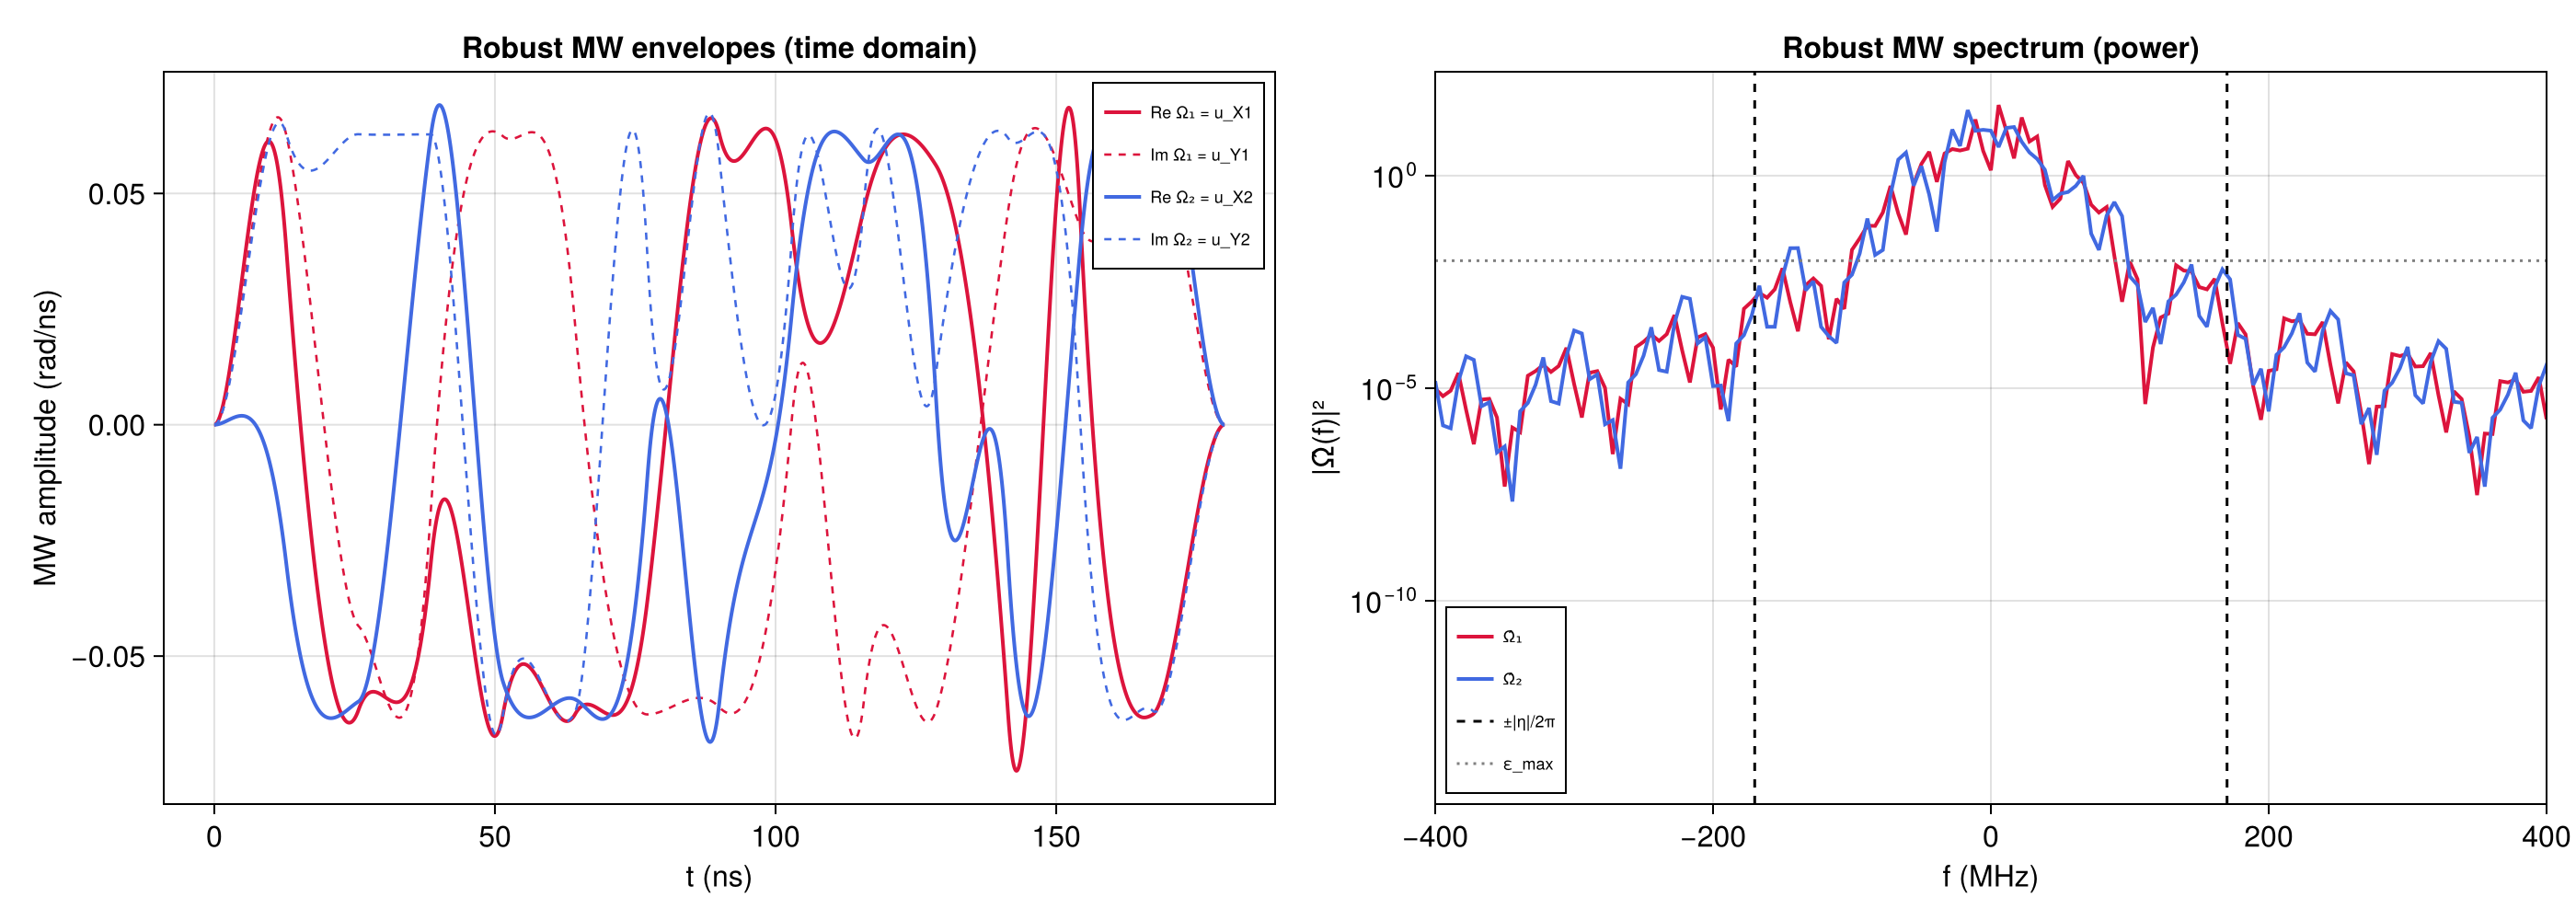

In [21]:
 # Spectral content of the optimized robust MW pulse

  # Sample the spline densely for a clean FFT
  N_dense_mw = 16384
  ts_dense   = collect(LinRange(0.0, T_MW_NS, N_dense_mw))
  dt_dense   = ts_dense[2] - ts_dense[1]
  pulse_loc  = CubicSplinePulse(traj_robust[:u], traj_robust[:du], vec(traj_robust[:t]))
  us_dense   = sample(pulse_loc, ts_dense)

  # Per-qubit complex MW envelopes
  Ω_1 = us_dense[1, :] .+ im .* us_dense[2, :]
  Ω_2 = us_dense[3, :] .+ im .* us_dense[4, :]

  # FFTs
  Ω_1_hat = fftshift(fft(Ω_1)) .* dt_dense
  Ω_2_hat = fftshift(fft(Ω_2)) .* dt_dense
  fs_MHz  = fftshift(fftfreq(N_dense_mw, 1.0 / dt_dense)) .* 1e3

  # Probe at ±|η|/2π
  i_pos = argmin(abs.(fs_MHz .- η_MHz))
  i_neg = argmin(abs.(fs_MHz .+ η_MHz))
  @printf("MW spectrum at ±%.0f MHz (vs ε_max = %.0e):\n", η_MHz, ε_MAX)
  @printf("  |Ω̂_1(+η)|² = %.3e    |Ω̂_1(−η)|² = %.3e\n", abs2(Ω_1_hat[i_pos]), abs2(Ω_1_hat[i_neg]))
  @printf("  |Ω̂_2(+η)|² = %.3e    |Ω̂_2(−η)|² = %.3e\n", abs2(Ω_2_hat[i_pos]), abs2(Ω_2_hat[i_neg]))

  fig6 = Figure(size = (1400, 500), fontsize = 16)

  ax_t = Axis(fig6[1, 1]; xlabel = "t (ns)", ylabel = "MW amplitude (rad/ns)",
      title = "Robust MW envelopes (time domain)")
  lines!(ax_t, ts_dense, real.(Ω_1); color = :crimson, linewidth = 2.0, label = "Re Ω₁ = u_X1")
  lines!(ax_t, ts_dense, imag.(Ω_1); color = :crimson, linewidth = 1.3, linestyle = :dash, label = "Im Ω₁ = u_Y1")
  lines!(ax_t, ts_dense, real.(Ω_2); color = :royalblue, linewidth = 2.0, label = "Re Ω₂ = u_X2")
  lines!(ax_t, ts_dense, imag.(Ω_2); color = :royalblue, linewidth = 1.3, linestyle = :dash, label = "Im Ω₂ = u_Y2")
  axislegend(ax_t; position = :rt, labelsize = 9)

  ax_f = Axis(fig6[1, 2]; xlabel = "f (MHz)", ylabel = "|Ω̂(f)|²",
      yscale = log10, title = "Robust MW spectrum (power)")
  lines!(ax_f, fs_MHz, max.(abs2.(Ω_1_hat), 1e-14); color = :crimson, linewidth = 2.0, label = "Ω̂₁")
  lines!(ax_f, fs_MHz, max.(abs2.(Ω_2_hat), 1e-14); color = :royalblue, linewidth = 2.0, label = "Ω̂₂")
  vlines!(ax_f, [η_MHz, -η_MHz]; color = :black, linestyle = :dash, linewidth = 1.5, label = "±|η|/2π")
  hlines!(ax_f, [ε_MAX]; color = :gray, linestyle = :dot, linewidth = 1.5, label = "ε_max")
  xlims!(ax_f, -400, 400)
  axislegend(ax_f; position = :lb, labelsize = 9)

  save(joinpath(@__DIR__, "mw_spectrum_$(RUN_TAG).png"), fig6; px_per_unit = 4)
  display(fig6)
  fig6